<a href="https://colab.research.google.com/github/SharathkumaraKR/Credit-Risk-Model/blob/Feature-Engineering/Credit_Risk_Model_(Kaggle).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_curve, auc
from sklearn.feature_selection import f_classif
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import chi2_contingency

In [2]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("somyaagarwal69/loan-data-2015")
print("Path to dataset files:", path)

# List files inside the downloaded folder
files = os.listdir(path)
print("Files:", files)

# Find the first CSV file (most Kaggle datasets contain CSV)
csv_files = [f for f in files if f.endswith(".csv")]

if csv_files:
    file_path = os.path.join(path, csv_files[0])
    print("Loading:", file_path)

    df = pd.read_csv(file_path)
    print(df.head())
else:
    print("No CSV found — check file extension.")


100%|██████████| 40.1M/40.1M [00:00<00:00, 47.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/somyaagarwal69/loan-data-2015/versions/1
Files: ['loan_data_2015.csv']
Loading: /root/.cache/kagglehub/datasets/somyaagarwal69/loan-data-2015/versions/1/loan_data_2015.csv


/tmp/ipykernel_3659/1730898842.py:20: DtypeWarning: Columns (19,47,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  60516983   64537751      20000        20000            20000   36 months   
1  60187139   64163931      11000        11000            11000   36 months   
2  60356453   64333218       7000         7000             7000   36 months   
3  59955769   63900496      10000        10000            10000   36 months   
4  58703693   62544456       9550         9550             9550   36 months   

   int_rate  installment grade sub_grade  ... total_bal_il il_util  \
0     12.29       667.06     C        C1  ...          NaN     NaN   
1     12.69       369.00     C        C2  ...          NaN     NaN   
2      9.99       225.84     B        B3  ...          NaN     NaN   
3     10.99       327.34     B        B4  ...          NaN     NaN   
4     19.99       354.87     E        E4  ...          NaN     NaN   

  open_rv_12m  open_rv_24m max_bal_bc all_util total_rev_hi_lim inq_fi  \
0         NaN          NaN    

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421094 entries, 0 to 421093
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           421094 non-null  int64  
 1   member_id                    421094 non-null  int64  
 2   loan_amnt                    421094 non-null  int64  
 3   funded_amnt                  421094 non-null  int64  
 4   funded_amnt_inv              421094 non-null  int64  
 5   term                         421094 non-null  object 
 6   int_rate                     421094 non-null  float64
 7   installment                  421094 non-null  float64
 8   grade                        421094 non-null  object 
 9   sub_grade                    421094 non-null  object 
 10  emp_title                    397220 non-null  object 
 11  emp_length                   397277 non-null  object 
 12  home_ownership               421094 non-null  object 
 13 

In [4]:
pd.options.display.max_columns = None

In [5]:
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,60516983,64537751,20000,20000,20000,36 months,12.29,667.06,C,C1,Accounting Clerk,1 year,OWN,65000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,542xx,WI,20.72,0,Sep-00,1,NaN,NaN,25,0,31578,77.0,42,w,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,NaN,0.00,NaN,Jan-16,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,0,52303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41000,NaN,NaN,NaN
1,60187139,64163931,11000,11000,11000,36 months,12.69,369.00,C,C2,Accounts Payable Lead,7 years,MORTGAGE,40000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,235xx,VA,24.57,0,Sep-02,0,36.0,80.0,13,1,5084,38.8,41,w,0.00,0.00,10043.49,10043.49,9942.67,100.81,0.0,0.0,0.0,Oct-15,10059.00,NaN,Jan-16,0,79.0,1,INDIVIDUAL,NaN,NaN,NaN,0,332,175731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13100,NaN,NaN,NaN
2,60356453,64333218,7000,7000,7000,36 months,9.99,225.84,B,B3,Nurse,6 years,MORTGAGE,32000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,350xx,AL,32.41,0,Feb-06,1,NaN,NaN,18,0,12070,74.0,36,f,0.00,0.00,221.96,221.96,167.56,54.40,0.0,0.0,0.0,Oct-15,225.84,NaN,Jan-16,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,0,202012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16300,NaN,NaN,NaN
3,59955769,63900496,10000,10000,10000,36 months,10.99,327.34,B,B4,Service Manager,10+ years,MORTGAGE,48000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,Credit card refinancing,483xx,MI,30.98,0,Oct-99,2,NaN,NaN,18,0,22950,66.0,41,f,0.00,0.00,315.13,315.13,235.76,79.37,0.0,0.0,0.0,Oct-15,327.34,NaN,Jan-16,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,0,108235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34750,NaN,NaN,NaN
4,58703693,62544456,9550,9550,9550,36 months,19.99,354.87,E,E4,NaN,NaN,RENT,32376.0,Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,546xx,WI,32.54,0,Nov-99,3,69.0,NaN,9,0,4172,29.6,26,w,0.00,0.00,333.66,333.66,195.78,137.88,0.0,0.0,0.0,Oct-15,354.87,NaN,Jan-16,0,69.0,1,INDIVIDUAL,NaN,NaN,NaN,0,0,45492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14100,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421089,37257620,40030388,25000,25000,25000,36 months,20.99,941.75,E,E4,shop foreman,10+ years,MORTGAGE,55000.0,Verified,Jan-15,Late (31-120 days),n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,380xx,TN,31.22,0,Oct-99,1,NaN,NaN,13,0,22438,63.2,18,f,20128.91,20128.91,8417.44,8417.44,4871.09,3546.35,0.0,0.0,0.0,Oct-15,941.75,Feb-16,Jan-16,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,0,167189,NaN,NaN,NaN,NaN,NaN,N

In [6]:
loan_data = df

In [7]:
# get a list of columns that have more than 80% null values
na_values = loan_data.isnull().mean()
na_values[na_values>0.8]

,0
desc,0.999893
mths_since_last_record,0.823282
annual_inc_joint,0.998786
dti_joint,0.998791
verification_status_joint,0.998786
open_acc_6m,0.949246
open_il_6m,0.949246
open_il_12m,0.949246
open_il_24m,0.949246
mths_since_rcnt_il,0.950581


In [8]:
loan_data.dropna(thresh = loan_data.shape[0] * 0.2, axis = 1, inplace = True)


'''
drop redundant and forward-looking columns
redundant like id, member_id, title, etc.
forward-looking like recoveries, collection_recovery_fee, etc.
drop sub_grade as same information is captured in grade column
drop next_pymnt_d since, given that our data is historical and this column is supposed to have future dates, will not make sense for our model
'''


'\ndrop redundant and forward-looking columns\nredundant like id, member_id, title, etc.\nforward-looking like recoveries, collection_recovery_fee, etc.\ndrop sub_grade as same information is captured in grade column\ndrop next_pymnt_d since, given that our data is historical and this column is supposed to have future dates, will not make sense for our model\n'

In [9]:
loan_data

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,60516983,64537751,20000,20000,20000,36 months,12.29,667.06,C,C1,Accounting Clerk,1 year,OWN,65000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,542xx,WI,20.72,0,Sep-00,1,NaN,25,0,31578,77.0,42,w,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,NaN,0.00,NaN,Jan-16,0,NaN,1,INDIVIDUAL,0,0,52303,41000
1,60187139,64163931,11000,11000,11000,36 months,12.69,369.00,C,C2,Accounts Payable Lead,7 years,MORTGAGE,40000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,235xx,VA,24.57,0,Sep-02,0,36.0,13,1,5084,38.8,41,w,0.00,0.00,10043.49,10043.49,9942.67,100.81,0.0,0.0,0.0,Oct-15,10059.00,NaN,Jan-16,0,79.0,1,INDIVIDUAL,0,332,175731,13100
2,60356453,64333218,7000,7000,7000,36 months,9.99,225.84,B,B3,Nurse,6 years,MORTGAGE,32000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,350xx,AL,32.41,0,Feb-06,1,NaN,18,0,12070,74.0,36,f,0.00,0.00,221.96,221.96,167.56,54.40,0.0,0.0,0.0,Oct-15,225.84,NaN,Jan-16,0,NaN,1,INDIVIDUAL,0,0,202012,16300
3,59955769,63900496,10000,10000,10000,36 months,10.99,327.34,B,B4,Service Manager,10+ years,MORTGAGE,48000.0,Source Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,credit_card,Credit card refinancing,483xx,MI,30.98,0,Oct-99,2,NaN,18,0,22950,66.0,41,f,0.00,0.00,315.13,315.13,235.76,79.37,0.0,0.0,0.0,Oct-15,327.34,NaN,Jan-16,0,NaN,1,INDIVIDUAL,0,0,108235,34750
4,58703693,62544456,9550,9550,9550,36 months,19.99,354.87,E,E4,NaN,NaN,RENT,32376.0,Verified,Sep-15,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,546xx,WI,32.54,0,Nov-99,3,69.0,9,0,4172,29.6,26,w,0.00,0.00,333.66,333.66,195.78,137.88,0.0,0.0,0.0,Oct-15,354.87,NaN,Jan-16,0,69.0,1,INDIVIDUAL,0,0,45492,14100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421089,37257620,40030388,25000,25000,25000,36 months,20.99,941.75,E,E4,shop foreman,10+ years,MORTGAGE,55000.0,Verified,Jan-15,Late (31-120 days),n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,380xx,TN,31.22,0,Oct-99,1,NaN,13,0,22438,63.2,18,f,20128.91,20128.91,8417.44,8417.44,4871.09,3546.35,0.0,0.0,0.0,Oct-15,941.75,Feb-16,Jan-16,0,NaN,1,INDIVIDUAL,0,0,167189,35500
421090,35998858,38700420,5875,5875,5875,36 months,15.59,205.37,D,D1,Elementary School Teacher,3 years,MORTGAGE,41000.0,Verified,Jan-15,Late (31-120 days),n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,292xx,SC,26.70,0,Jun-06,0,NaN,10,0,7594,61.7,28,f,4518.05,4518.05,2043.52,2043.52,1356.95,686.57,0.0,0.0,0.0,Nov-15,410.74,Feb-16,Jan-16,0,NaN,1,INDIVIDUAL,0,0,174030,12300
421091,37317288,40080027,10000,10000,10000,60 months,23.99,287.63,F,F2,Sales,2 years,RENT,35000.0,Verified,Jan-15,Late (31-120 days),n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,891xx,NV,8.30,0,Aug-06,3,28.0,6,0,4317,60.2,12,w,9146.43,9146.43,2577.01,2577.01,853.57,1708.44,

In [10]:
loan_data.drop(columns = ['id', 'member_id', 'sub_grade', 'emp_title', 'url', 'title', 'zip_code', 'next_pymnt_d',
                          'recoveries', 'collection_recovery_fee', 'total_rec_prncp', 'total_rec_late_fee'], inplace = True)

In [11]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421094 entries, 0 to 421093
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    421094 non-null  int64  
 1   funded_amnt                  421094 non-null  int64  
 2   funded_amnt_inv              421094 non-null  int64  
 3   term                         421094 non-null  object 
 4   int_rate                     421094 non-null  float64
 5   installment                  421094 non-null  float64
 6   grade                        421094 non-null  object 
 7   emp_length                   397277 non-null  object 
 8   home_ownership               421094 non-null  object 
 9   annual_inc                   421094 non-null  float64
 10  verification_status          421094 non-null  object 
 11  issue_d                      421094 non-null  object 
 12  loan_status                  421094 non-null  object 
 13 

In [12]:
# explore the unique values in loan_status column
loan_data['loan_status'].value_counts(normalize = True)

,proportion
loan_status,
Current,0.896600
Fully Paid,0.054582
Issued,0.020091
Late (31-120 days),0.011140
In Grace Period,0.007378
Charged Off,0.006585
Late (16-30 days),0.002705
Default,0.000919


In [13]:
loan_data['good_bad'] = np.where(
    loan_data.loc[:, 'loan_status'].isin([
        'Charged Off',
        'Default',
        'Late (31-120 days)'
    ]),
    0,  # Bad loan
    1   # Good loan
)

loan_data.drop(columns=['loan_status'], inplace=True)

In [14]:
loan_data

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_int,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,good_bad
0,20000,20000,20000,36 months,12.29,667.06,C,1 year,OWN,65000.0,Source Verified,Sep-15,n,debt_consolidation,WI,20.72,0,Sep-00,1,NaN,25,0,31578,77.0,42,w,0.00,0.00,0.00,0.00,0.00,NaN,0.00,Jan-16,0,NaN,1,INDIVIDUAL,0,0,52303,41000,0
1,11000,11000,11000,36 months,12.69,369.00,C,7 years,MORTGAGE,40000.0,Source Verified,Sep-15,n,debt_consolidation,VA,24.57,0,Sep-02,0,36.0,13,1,5084,38.8,41,w,0.00,0.00,10043.49,10043.49,100.81,Oct-15,10059.00,Jan-16,0,79.0,1,INDIVIDUAL,0,332,175731,13100,0
2,7000,7000,7000,36 months,9.99,225.84,B,6 years,MORTGAGE,32000.0,Source Verified,Sep-15,n,debt_consolidation,AL,32.41,0,Feb-06,1,NaN,18,0,12070,74.0,36,f,0.00,0.00,221.96,221.96,54.40,Oct-15,225.84,Jan-16,0,NaN,1,INDIVIDUAL,0,0,202012,16300,0
3,10000,10000,10000,36 months,10.99,327.34,B,10+ years,MORTGAGE,48000.0,Source Verified,Sep-15,n,credit_card,MI,30.98,0,Oct-99,2,NaN,18,0,22950,66.0,41,f,0.00,0.00,315.13,315.13,79.37,Oct-15,327.34,Jan-16,0,NaN,1,INDIVIDUAL,0,0,108235,34750,0
4,9550,9550,9550,36 months,19.99,354.87,E,NaN,RENT,32376.0,Verified,Sep-15,n,debt_consolidation,WI,32.54,0,Nov-99,3,69.0,9,0,4172,29.6,26,w,0.00,0.00,333.66,333.66,137.88,Oct-15,354.87,Jan-16,0,69.0,1,INDIVIDUAL,0,0,45492,14100,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421089,25000,25000,25000,36 months,20.99,941.75,E,10+ years,MORTGAGE,55000.0,Verified,Jan-15,n,debt_consolidation,TN,31.22,0,Oct-99,1,NaN,13,0,22438,63.2,18,f,20128.91,20128.91,8417.44,8417.44,3546.35,Oct-15,941.75,Jan-16,0,NaN,1,INDIVIDUAL,0,0,167189,35500,0
421090,5875,5875,5875,36 months,15.59,205.37,D,3 years,MORTGAGE,41000.0,Verified,Jan-15,n,debt_consolidation,SC,26.70,0,Jun-06,0,NaN,10,0,7594,61.7,28,f,4518.05,4518.05,2043.52,2043.52,686.57,Nov-15,410.74,Jan-16,0,NaN,1,INDIVIDUAL,0,0,174030,12300,0
421091,10000,10000,10000,60 months,23.99,287.63,F,2 years,RENT,35000.0,Verified,Jan-15,n,debt_consolidation,NV,8.30,0,Aug-06,3,28.0,6,0,4317,60.2,12,w,9146.43,9146.43,2577.01,2577.01,1708.44,Oct-15,590.26,Jan-16,0,31.0,1,INDIVIDUAL,0,0,8529,7200,0
421092,19600,19600,19600,60 months,14.31,459.22,C,NaN,OWN,49000.0,Verified,Jan-15,n,credit_card,FL,22.58,1,Jan-90,2,6.0,22,0,141120,26.7,48,w,17286.47,17286.47,4064.94,4064.94,1751.41,Sep-15,459.22,Jan-16,0,NaN,1,INDIVIDUAL,0,0,141120,233000,0


In [15]:
X = loan_data.drop('good_bad', axis = 1)
y = loan_data['good_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# specifically hard copying the training sets to avoid Pandas' SetttingWithCopyWarning when we play around with this data later on.
# as noted [here](https://github.com/scikit-learn/scikit-learn/issues/8723), this is currently an open issue between Pandas and Scikit-Learn teams
X_train, X_test = X_train.copy(), X_test.copy()

## General Data Cleaning

In [16]:
def emp_length_converter(df, column):

    df[column] = (
        df[column]
        .str.replace(r'\+ years', '', regex=True)
        .str.replace(r'\+ year', '', regex=True)
        .str.replace(r'\+', '', regex=True)
        .str.replace(r'< 1 year', '0', regex=True)
        .str.replace(r' years', '', regex=True)
        .str.replace(r' year', '', regex=True)
    )

    df[column] = pd.to_numeric(df[column], errors='coerce').fillna(0)
emp_length_converter(X_train, 'emp_length')



def loan_term_converter(df, column):
    df[column] = pd.to_numeric(df[column].str.replace(' months', ''))

loan_term_converter(X_train, 'term')

In [ ]:
X_train

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_int,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
304531,6075,6075,6075,36,21.67,230.98,E,10.0,RENT,61944.0,Verified,Apr-15,n,debt_consolidation,MD,22.51,2,Dec-98,1,8.0,10,2,1295,21.6,44,f,4901.26,4901.26,2064.19,2064.19,890.45,Jan-16,230.98,Jan-16,0,8.0,1,INDIVIDUAL,0,5850,56586,6000
35795,28000,28000,28000,36,7.26,867.90,A,10.0,MORTGAGE,122000.0,Verified,Dec-15,n,debt_consolidation,IN,34.63,1,Apr-83,1,12.0,37,0,67108,44.0,71,w,27301.50,27301.50,856.61,856.61,158.11,Jan-16,867.90,Jan-16,0,NaN,1,INDIVIDUAL,0,0,346548,153100
152875,20000,20000,20000,36,12.69,670.90,C,10.0,RENT,96600.0,Verified,Aug-15,n,credit_card,FL,22.36,0,Nov-79,2,NaN,16,1,20530,71.8,44,w,18133.05,18133.05,2747.05,2747.05,880.10,Jan-16,670.90,Jan-16,0,NaN,1,INDIVIDUAL,0,0,59914,28600
130626,14950,14950,14950,36,13.33,506.11,C,2.0,RENT,34000.0,Source Verified,Sep-15,n,debt_consolidation,TX,30.85,0,Dec-06,1,NaN,17,0,9317,48.0,27,f,13567.01,13567.01,2013.37,2013.37,630.38,Jan-16,506.11,Jan-16,0,NaN,1,INDIVIDUAL,0,0,96630,19400
264071,18000,18000,18000,60,12.29,403.05,C,6.0,MORTGAGE,106000.0,Source Verified,May-15,n,debt_consolidation,CT,11.72,1,Mar-89,0,6.0,10,1,6877,48.8,19,f,16186.38,16186.38,3212.11,3212.11,1398.49,Jan-16,403.05,Jan-16,0,52.0,1,INDIVIDUAL,0,0,221460,14100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297973,15000,15000,15000,36,7.89,469.29,A,10.0,MORTGAGE,59000.0,Source Verified,Apr-15,n,credit_card,MO,30.74,0,Mar-94,0,44.0,10,0,9655,55.5,26,f,11965.54,11965.54,3741.17,3741.17,706.71,Jan-16,469.29,Jan-16,0,NaN,1,INDIVIDUAL,0,0,123363,17400
206060,15000,15000,15000,60,9.99,318.64,B,10.0,MORTGAGE,72800.0,Not Verified,Jul-15,n,debt_consolidation,GA,20.92,0,Dec-07,0,NaN,7,0,5263,67.5,14,w,13812.94,13812.94,1903.52,1903.52,716.46,Jan-16,318.64,Jan-16,0,NaN,1,INDIVIDUAL,0,0,153551,7800
401501,16000,16000,16000,36,12.39,534.42,C,10.0,MORTGAGE,71000.0,Not Verified,Jan-15,n,other,TX,7.34,0,Sep-01,0,35.0,7,0,7606,46.7,27,w,0.00,0.00,16834.77,16834.77,834.77,Jun-15,14708.10,Dec-15,0,42.0,1,INDIVIDUAL,0,0,255833,16300
238152,20000,20000,20000,60,12.29,447.83,C,10.0,MORTGAGE,42000.0,Source Verified,Jun-15,n,home_improvement,MD,29.60,0,Nov-84,0,37.0,8,0,12912,34.8,13,w,18245.86,18245.86,3121.15,3121.15,1367.01,Jan-16,447.83,Jan-16,0,NaN,1,INDIVIDUAL,0,0,89141,37100


In [17]:
from dateutil.relativedelta import relativedelta

def date_columns(df, column):

    today_date = pd.to_datetime('2020-08-01')
    # convert to datetime format safely
    df[column] = pd.to_datetime(df[column], format="%b-%y", errors='coerce')
    # calculate difference in months using relativedelta
    df['mths_since_' + column] = df[column].apply(
        lambda x: relativedelta(today_date, x).years * 12 + relativedelta(today_date, x).months
        if pd.notnull(x) else np.nan
    )
    # replace negative values with max
    max_val = df['mths_since_' + column].max()
    df['mths_since_' + column] = df['mths_since_' + column].apply(lambda x: max_val if x < 0 else x)
    # fill NA with max
    df['mths_since_' + column].fillna(max_val, inplace=True)
    # drop original column
    df.drop(columns=[column], inplace=True)

date_columns(X_train, 'earliest_cr_line')
date_columns(X_train, 'issue_d')
date_columns(X_train, 'last_pymnt_d')
date_columns(X_train, 'last_credit_pull_d')

/tmp/ipykernel_3659/4021890405.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_' + column].fillna(max_val, inplace=True)
/tmp/ipykernel_3659/4021890405.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [18]:
X_train

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_int,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_last_credit_pull_d
304531,6075,6075,6075,36,21.67,230.98,E,10.0,RENT,61944.0,Verified,n,debt_consolidation,MD,22.51,2,1,8.0,10,2,1295,21.6,44,f,4901.26,4901.26,2064.19,2064.19,890.45,230.98,0,8.0,1,INDIVIDUAL,0,5850,56586,6000,260,64,55.0,55.0
35795,28000,28000,28000,36,7.26,867.90,A,10.0,MORTGAGE,122000.0,Verified,n,debt_consolidation,IN,34.63,1,1,12.0,37,0,67108,44.0,71,w,27301.50,27301.50,856.61,856.61,158.11,867.90,0,NaN,1,INDIVIDUAL,0,0,346548,153100,448,56,55.0,55.0
152875,20000,20000,20000,36,12.69,670.90,C,10.0,RENT,96600.0,Verified,n,credit_card,FL,22.36,0,2,NaN,16,1,20530,71.8,44,w,18133.05,18133.05,2747.05,2747.05,880.10,670.90,0,NaN,1,INDIVIDUAL,0,0,59914,28600,489,60,55.0,55.0
130626,14950,14950,14950,36,13.33,506.11,C,2.0,RENT,34000.0,Source Verified,n,debt_consolidation,TX,30.85,0,1,NaN,17,0,9317,48.0,27,f,13567.01,13567.01,2013.37,2013.37,630.38,506.11,0,NaN,1,INDIVIDUAL,0,0,96630,19400,164,59,55.0,55.0
264071,18000,18000,18000,60,12.29,403.05,C,6.0,MORTGAGE,106000.0,Source Verified,n,debt_consolidation,CT,11.72,1,0,6.0,10,1,6877,48.8,19,f,16186.38,16186.38,3212.11,3212.11,1398.49,403.05,0,52.0,1,INDIVIDUAL,0,0,221460,14100,377,63,55.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297973,15000,15000,15000,36,7.89,469.29,A,10.0,MORTGAGE,59000.0,Source Verified,n,credit_card,MO,30.74,0,0,44.0,10,0,9655,55.5,26,f,11965.54,11965.54,3741.17,3741.17,706.71,469.29,0,NaN,1,INDIVIDUAL,0,0,123363,17400,317,64,55.0,55.0
206060,15000,15000,15000,60,9.99,318.64,B,10.0,MORTGAGE,72800.0,Not Verified,n,debt_consolidation,GA,20.92,0,0,NaN,7,0,5263,67.5,14,w,13812.94,13812.94,1903.52,1903.52,716.46,318.64,0,NaN,1,INDIVIDUAL,0,0,153551,7800,152,61,55.0,55.0
401501,16000,16000,16000,36,12.39,534.42,C,10.0,MORTGAGE,71000.0,Not Verified,n,other,TX,7.34,0,0,35.0,7,0,7606,46.7,27,w,0.00,0.00,16834.77,16834.77,834.77,14708.10,0,42.0,1,INDIVIDUAL,0,0,255833,16300,227,67,62.0,56.0
238152,20000,20000,20000,60,12.29,447.83,C,10.0,MORTGAGE,42000.0,Source Verified,n,home_improvement,MD,29.60,0,0,37.0,8,0,12912,34.8,13,w,18245.86,18245.86,3121.15,3121.15,1367.01,447.83,0,NaN,1,INDIVIDUAL,0,0,89141,37100,429,62,55.0,55.0


In [19]:
# first divide training data into categorical and numerical subsets
X_train_cat = X_train.select_dtypes(include = 'object').copy()
X_train_num = X_train.select_dtypes(include = 'number').copy()

In [20]:
X_train_cat

,grade,home_ownership,verification_status,pymnt_plan,purpose,addr_state,initial_list_status,application_type
304531,E,RENT,Verified,n,debt_consolidation,MD,f,INDIVIDUAL
35795,A,MORTGAGE,Verified,n,debt_consolidation,IN,w,INDIVIDUAL
152875,C,RENT,Verified,n,credit_card,FL,w,INDIVIDUAL
130626,C,RENT,Source Verified,n,debt_consolidation,TX,f,INDIVIDUAL
264071,C,MORTGAGE,Source Verified,n,debt_consolidation,CT,f,INDIVIDUAL
...,...,...,...,...,...,...,...,...
297973,A,MORTGAGE,Source Verified,n,credit_card,MO,f,INDIVIDUAL
206060,B,MORTGAGE,Not Verified,n,debt_consolidation,GA,w,INDIVIDUAL
401501,C,MORTGAGE,Not Verified,n,other,TX,w,INDIVIDUAL
238152,C,MORTGAGE,Source Verified,n,home_improvement,MD,w,INDIVIDUAL


In [21]:
X_train_num

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_int,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_last_credit_pull_d
304531,6075,6075,6075,36,21.67,230.98,10.0,61944.0,22.51,2,1,8.0,10,2,1295,21.6,44,4901.26,4901.26,2064.19,2064.19,890.45,230.98,0,8.0,1,0,5850,56586,6000,260,64,55.0,55.0
35795,28000,28000,28000,36,7.26,867.90,10.0,122000.0,34.63,1,1,12.0,37,0,67108,44.0,71,27301.50,27301.50,856.61,856.61,158.11,867.90,0,NaN,1,0,0,346548,153100,448,56,55.0,55.0
152875,20000,20000,20000,36,12.69,670.90,10.0,96600.0,22.36,0,2,NaN,16,1,20530,71.8,44,18133.05,18133.05,2747.05,2747.05,880.10,670.90,0,NaN,1,0,0,59914,28600,489,60,55.0,55.0
130626,14950,14950,14950,36,13.33,506.11,2.0,34000.0,30.85,0,1,NaN,17,0,9317,48.0,27,13567.01,13567.01,2013.37,2013.37,630.38,506.11,0,NaN,1,0,0,96630,19400,164,59,55.0,55.0
264071,18000,18000,18000,60,12.29,403.05,6.0,106000.0,11.72,1,0,6.0,10,1,6877,48.8,19,16186.38,16186.38,3212.11,3212.11,1398.49,403.05,0,52.0,1,0,0,221460,14100,377,63,55.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297973,15000,15000,15000,36,7.89,469.29,10.0,59000.0,30.74,0,0,44.0,10,0,9655,55.5,26,11965.54,11965.54,3741.17,3741.17,706.71,469.29,0,NaN,1,0,0,123363,17400,317,64,55.0,55.0
206060,15000,15000,15000,60,9.99,318.64,10.0,72800.0,20.92,0,0,NaN,7,0,5263,67.5,14,13812.94,13812.94,1903.52,1903.52,716.46,318.64,0,NaN,1,0,0,153551,7800,152,61,55.0,55.0
401501,16000,16000,16000,36,12.39,534.42,10.0,71000.0,7.34,0,0,35.0,7,0,7606,46.7,27,0.00,0.00,16834.77,16834.77,834.77,14708.10,0,42.0,1,0,0,255833,16300,227,67,62.0,56.0
238152,20000,20000,20000,60,12.29,447.83,10.0,42000.0,29.60,0,0,37.0,8,0,12912,34.8,13,18245.86,18245.86,3121.15,3121.15,1367.01,447.83,0,NaN,1,0,0,89141,37100,429,62,55.0,55.0


In [23]:
# define an empty dictionary to store chi-squared test results
chi2_check = {}

# loop over each column in the training set to calculate chi-statistic with the target variable
for column in X_train_cat:
    chi, p, dof, ex = chi2_contingency(pd.crosstab(y_train, X_train_cat[column]))
    chi2_check.setdefault('Feature',[]).append(column)
    chi2_check.setdefault('p-value',[]).append(round(p, 10))

# convert the dictionary to a DF
chi2_result = pd.DataFrame(data = chi2_check)
chi2_result.sort_values(by = ['p-value'], ascending = True, ignore_index = True, inplace = True)
chi2_result

,Feature,p-value
0,grade,0.000000
1,home_ownership,0.000000
2,verification_status,0.000000
3,purpose,0.000000
4,initial_list_status,0.000000
5,addr_state,0.000000
6,application_type,0.028142
7,pymnt_plan,1.000000


In [24]:
# since f_class_if does not accept missing values, we will do a very crude imputation of missing values
X_train_num.fillna(X_train_num.mean(), inplace = True)
# Calculate F Statistic and corresponding p values
F_statistic, p_values = f_classif(X_train_num, y_train)
# convert to a DF
ANOVA_F_table = pd.DataFrame(data = {'Numerical_Feature': X_train_num.columns.values, 'F-Score': F_statistic, 'p values': p_values.round(decimals=10)})
ANOVA_F_table.sort_values(by = ['F-Score'], ascending = False, ignore_index = True, inplace = True)
ANOVA_F_table

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [25] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Numerical_Feature,F-Score,p values
0,mths_since_last_pymnt_d,9912.165901,0.000000e+00
1,mths_since_issue_d,5022.870198,0.000000e+00
2,int_rate,4335.700503,0.000000e+00
3,out_prncp,1302.251647,0.000000e+00
4,out_prncp_inv,1302.222886,0.000000e+00
5,inq_last_6mths,525.882831,0.000000e+00
6,mths_since_last_credit_pull_d,468.083823,0.000000e+00
7,total_pymnt,211.946776,0.000000e+00
8,total_pymnt_inv,211.869294,0.000000e+00
9,last_pymnt_amnt,206.562975,0.000000e+00


Text(0.5, 1.0, 'Pearson correlation')

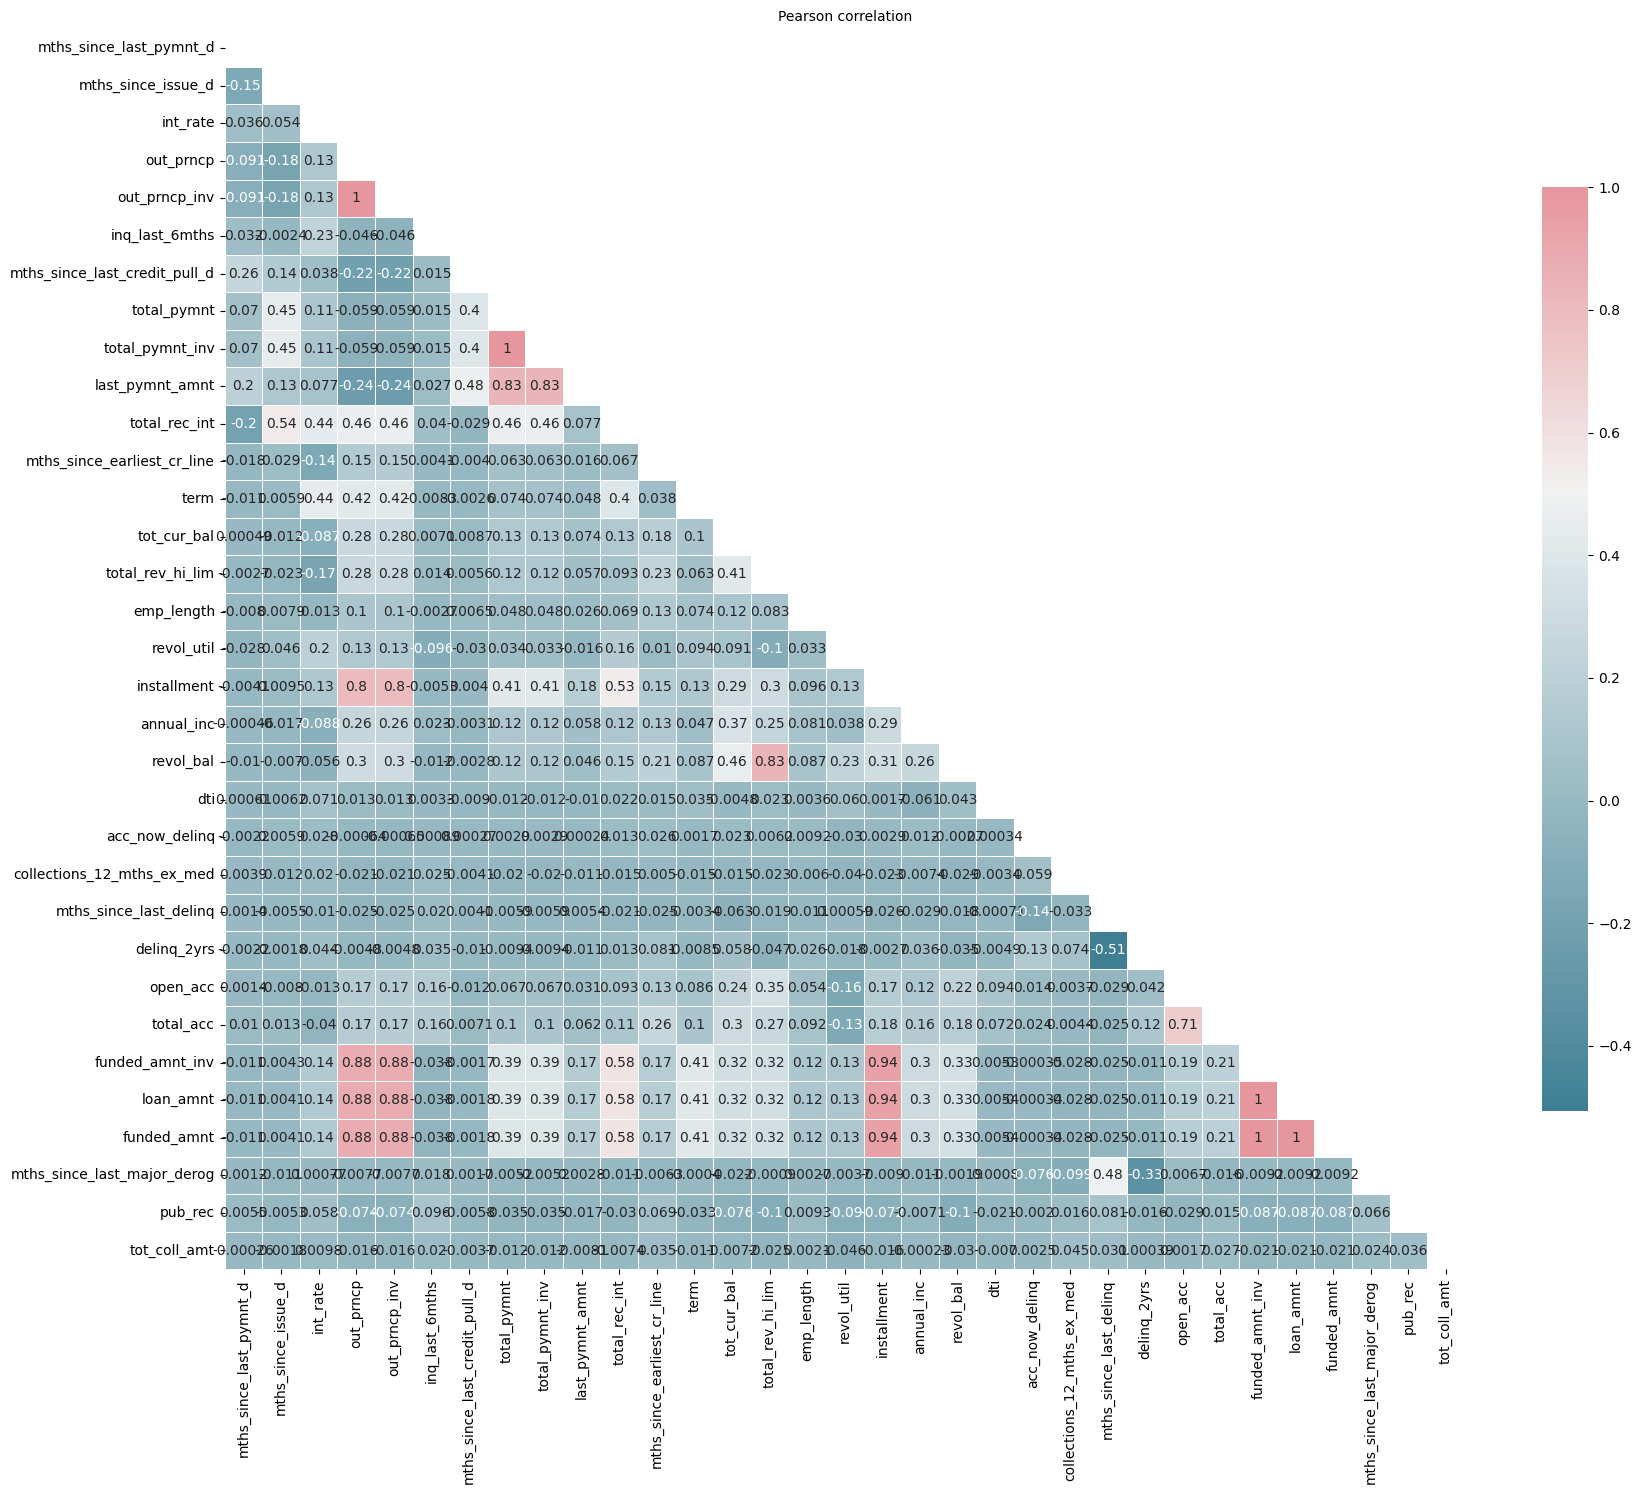

In [ ]:
# save the top 20 numerical features in a list
top_num_features = ANOVA_F_table.iloc[:33,0].to_list()
# calculate pair-wise correlations between them
corrmat = X_train_num[top_num_features].corr()
mask = np.triu(np.ones_like(corrmat, dtype=np.bool))
f, ax = plt.subplots(figsize=(20,20))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corrmat, cmap= cmap, mask= mask, vmax=1, center=0.5,
            square=True, linewidths=.5, cbar_kws={"shrink": .6},annot=True)

plt.title("Pearson correlation", fontsize =10)


In [27]:
# Define a helper function to drop the 4 categorical features with least p-values for chi squared test, 14 numerical features with least F-Statistic
# and 2 numerical features with high multicollinearity
drop_columns_list = ANOVA_F_table.iloc[33:, 0].to_list()
drop_columns_list.extend(chi2_result.iloc[4:, 0].to_list())
drop_columns_list.extend(['out_prncp_inv', 'total_pymnt_inv','funded_amnt','funded_amnt_inv'])

def col_to_drop(df, columns_list):
    df.drop(columns = columns_list, inplace = True)

# apply to X_train
col_to_drop(X_train, drop_columns_list)

KeyError: "['policy_code', 'initial_list_status', 'addr_state', 'application_type', 'pymnt_plan', 'out_prncp_inv', 'total_pymnt_inv', 'funded_amnt', 'funded_amnt_inv'] not found in axis"

In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336875 entries, 304531 to 312076
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   loan_amnt                      336875 non-null  int64  
 1   term                           336875 non-null  int64  
 2   int_rate                       336875 non-null  float64
 3   installment                    336875 non-null  float64
 4   grade                          336875 non-null  object 
 5   emp_length                     336875 non-null  float64
 6   home_ownership                 336875 non-null  object 
 7   annual_inc                     336875 non-null  float64
 8   verification_status            336875 non-null  object 
 9   purpose                        336875 non-null  object 
 10  dti                            336875 non-null  float64
 11  delinq_2yrs                    336875 non-null  int64  
 12  inq_last_6mths                

In [29]:
X_train

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,total_rec_int,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_last_credit_pull_d
304531,6075,36,21.67,230.98,E,10.0,RENT,61944.0,Verified,debt_consolidation,22.51,2,1,8.0,10,2,1295,21.6,44,4901.26,2064.19,890.45,230.98,0,8.0,0,5850,56586,6000,260,64,55.0,55.0
35795,28000,36,7.26,867.90,A,10.0,MORTGAGE,122000.0,Verified,debt_consolidation,34.63,1,1,12.0,37,0,67108,44.0,71,27301.50,856.61,158.11,867.90,0,NaN,0,0,346548,153100,448,56,55.0,55.0
152875,20000,36,12.69,670.90,C,10.0,RENT,96600.0,Verified,credit_card,22.36,0,2,NaN,16,1,20530,71.8,44,18133.05,2747.05,880.10,670.90,0,NaN,0,0,59914,28600,489,60,55.0,55.0
130626,14950,36,13.33,506.11,C,2.0,RENT,34000.0,Source Verified,debt_consolidation,30.85,0,1,NaN,17,0,9317,48.0,27,13567.01,2013.37,630.38,506.11,0,NaN,0,0,96630,19400,164,59,55.0,55.0
264071,18000,60,12.29,403.05,C,6.0,MORTGAGE,106000.0,Source Verified,debt_consolidation,11.72,1,0,6.0,10,1,6877,48.8,19,16186.38,3212.11,1398.49,403.05,0,52.0,0,0,221460,14100,377,63,55.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297973,15000,36,7.89,469.29,A,10.0,MORTGAGE,59000.0,Source Verified,credit_card,30.74,0,0,44.0,10,0,9655,55.5,26,11965.54,3741.17,706.71,469.29,0,NaN,0,0,123363,17400,317,64,55.0,55.0
206060,15000,60,9.99,318.64,B,10.0,MORTGAGE,72800.0,Not Verified,debt_consolidation,20.92,0,0,NaN,7,0,5263,67.5,14,13812.94,1903.52,716.46,318.64,0,NaN,0,0,153551,7800,152,61,55.0,55.0
401501,16000,36,12.39,534.42,C,10.0,MORTGAGE,71000.0,Not Verified,other,7.34,0,0,35.0,7,0,7606,46.7,27,0.00,16834.77,834.77,14708.10,0,42.0,0,0,255833,16300,227,67,62.0,56.0
238152,20000,60,12.29,447.83,C,10.0,MORTGAGE,42000.0,Source Verified,home_improvement,29.60,0,0,37.0,8,0,12912,34.8,13,18245.86,3121.15,1367.01,447.83,0,NaN,0,0,89141,37100,429,62,55.0,55.0


In [30]:
# function to create dummy variables
def dummy_creation(df, columns_list):
    df_dummies = []
    for col in columns_list:
        df_dummies.append(pd.get_dummies(df[col], prefix = col, prefix_sep = ':'))
    df_dummies = pd.concat(df_dummies, axis = 1)
    df = pd.concat([df, df_dummies], axis = 1)
    return df

# apply to our final four categorical variables
X_train = dummy_creation(X_train, ['grade', 'home_ownership', 'verification_status', 'purpose'])

In [32]:
X_train

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,total_rec_int,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_last_credit_pull_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding
304531,6075,36,21.67,230.98,E,10.0,RENT,61944.0,Verified,debt_consolidation,22.51,2,1,8.0,10,2,1295,21.6,44,4901.26,2064.19,890.45,230.98,0,8.0,0,5850,56586,6000,260,64,55.0,55.0,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False
35795,28000,36,7.26,867.90,A,10.0,MORTGAGE,122000.0,Verified,debt_consolidation,34.63,1,1,12.0,37,0,67108,44.0,71,27301.50,856.61,158.11,867.90,0,NaN,0,0,346548,153100,448,56,55.0,55.0,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False
152875,20000,36,12.69,670.90,C,10.0,RENT,96600.0,Verified,credit_card,22.36,0,2,NaN,16,1,20530,71.8,44,18133.05,2747.05,880.10,670.90,0,NaN,0,0,59914,28600,489,60,55.0,55.0,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False
130626,14950,36,13.33,506.11,C,2.0,RENT,34000.0,Source Verified,debt_consolidation,30.85,0,1,NaN,17,0,9317,48.0,27,13567.01,2013.37,630.38,506.11,0,NaN,0,0,96630,19400,164,59,55.0,55.0,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
264071,18000,60,12.29,403.05,C,6.0,MORTGAGE,106000.0,Source Verified,debt_consolidation,11.72,1,0,6.0,10,1,6877,48.8,19,16186.38,3212.11,1398.49,403.05,0,52.0,0,0,221460,14100,377,63,55.0,55.0,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297973,15000,36,7.89,469.29,A,10.0,MORTGAGE,59000.0,Source Verified,credit_card,30.74,0,0,44.0,10,0,9655,55.5,26,11965.54,3741.17,706.71,469.29,0,NaN,0,0,123363,17400,317,64,55.0,55.0,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
206060,15000,60,9.99,318.64,B,10.0,MORTGAGE,72800.0,Not Verified,debt_consolidation,20.92,0,0,NaN,7,0,5263,67.5,14,13812.94,1903.52,716.46,318.64,0,NaN,0,0,153551,7800,152,61,55.0,55.0,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
401501,16000,36,12.39,534.42,C,10.0,MORTGAGE,71000.0,Not Verified,other,7.34,0,0,35.0,7,0,7606,46.7,27,0.00,16834.77,834.77,14708.10,0,42.0,0,0,255833,16300,227,67,62.0,56.0,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2381

In [33]:
emp_length_converter(X_test, 'emp_length')
date_columns(X_test, 'earliest_cr_line')
date_columns(X_test, 'issue_d')
date_columns(X_test, 'last_pymnt_d')
date_columns(X_test, 'last_credit_pull_d')
loan_term_converter(X_test, 'term')
col_to_drop(X_test, drop_columns_list)
X_test = dummy_creation(X_test, ['grade', 'home_ownership', 'verification_status', 'purpose'])
# reindex the dummied test set variables to make sure all the feature columns in the train set are also available in the test set
X_test = X_test.reindex(labels=X_train.columns, axis=1, fill_value=0)

/tmp/ipykernel_3659/4021890405.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_' + column].fillna(max_val, inplace=True)
/tmp/ipykernel_3659/4021890405.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [34]:
## WoE Binning/Feature Engineering
X_train_prepr = X_train.copy()
y_train_prepr = y_train.copy()
X_test_prepr = X_test.copy()
y_test_prepr = y_test.copy()

In [41]:
# The function takes 3 arguments: a dataframe (X_train_prepr), a string (column name), and a dataframe (y_train_prepr).
# The function returns a dataframe as a result.
def woe_discrete(df, cat_variabe_name, y_df):
    df = pd.concat([df[cat_variabe_name], y_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [43]:
# We set the default style of the graphs to the seaborn style.
sns.set()
# Below we define a function for plotting WoE across categories that takes 2 arguments: a dataframe and a number.
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    y = df_WoE['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df_WoE.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

In [44]:
df_temp = woe_discrete(X_train_prepr, 'grade', y_train_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,1743,0.901893,0.005174,1572.0,171.0,0.004755,0.027225,-1.744921,NaN,NaN,0.632238
1,F,7869,0.932647,0.023359,7339.0,530.0,0.022199,0.084381,-1.335281,0.030754,0.409640,0.632238
2,E,27998,0.956604,0.083111,26783.0,1215.0,0.081015,0.193441,-0.870339,0.023957,0.464942,0.632238
3,D,50148,0.967496,0.148862,48518.0,1630.0,0.146760,0.259513,-0.570007,0.010892,0.300332,0.632238
4,C,96501,0.982601,0.286459,94822.0,1679.0,0.286823,0.267314,0.070441,0.015105,0.640448,0.632238
5,B,93959,0.991007,0.278914,93114.0,845.0,0.281657,0.134533,0.738881,0.008405,0.668440,0.632238
6,A,58657,0.996403,0.174121,58446.0,211.0,0.176791,0.033593,1.660639,0.005396,0.921757,0.632238


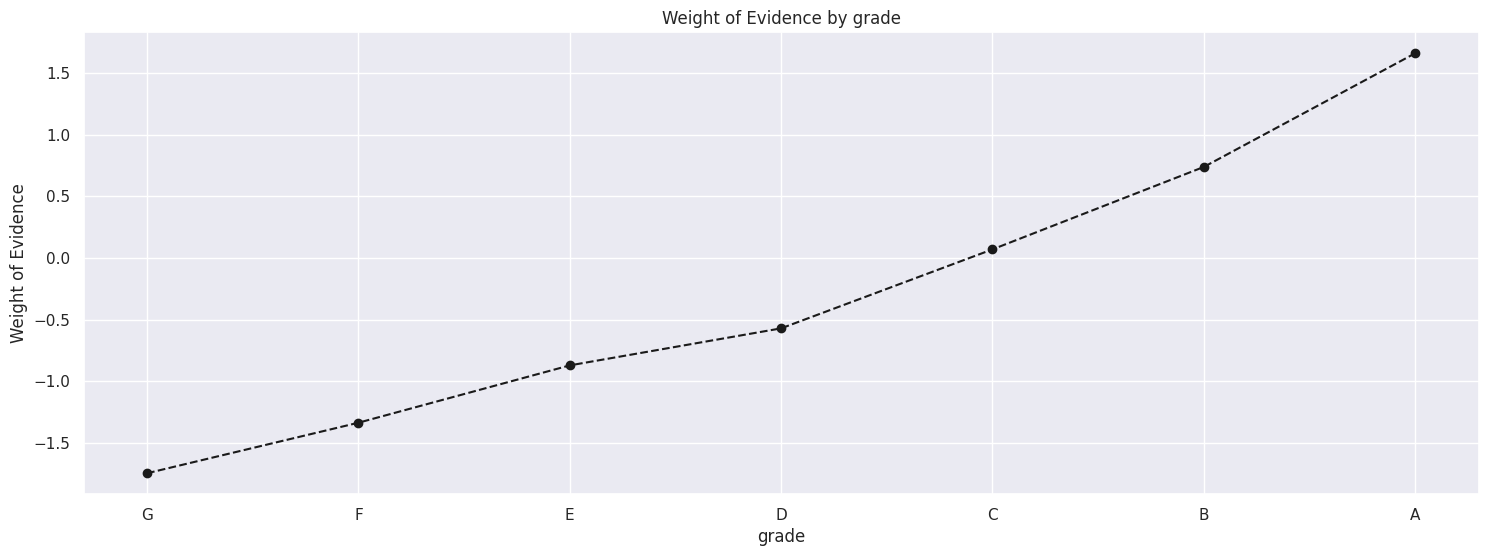

In [45]:
plot_by_woe(df_temp)

In [46]:
df_temp = woe_discrete(X_train_prepr, 'home_ownership', y_train_prepr)
df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,RENT,134297,0.976984,0.398655,131206.0,3091.0,0.396880,0.492119,-0.215088,NaN,NaN,inf
1,OWN,36571,0.981379,0.108560,35890.0,681.0,0.108562,0.108422,0.001290,0.004395,0.216378,inf
2,MORTGAGE,166005,0.984886,0.492779,163496.0,2509.0,0.494552,0.399459,0.213542,0.003507,0.212253,inf
3,ANY,2,1.000000,0.000006,2.0,0.0,0.000006,0.000000,inf,0.015114,inf,inf


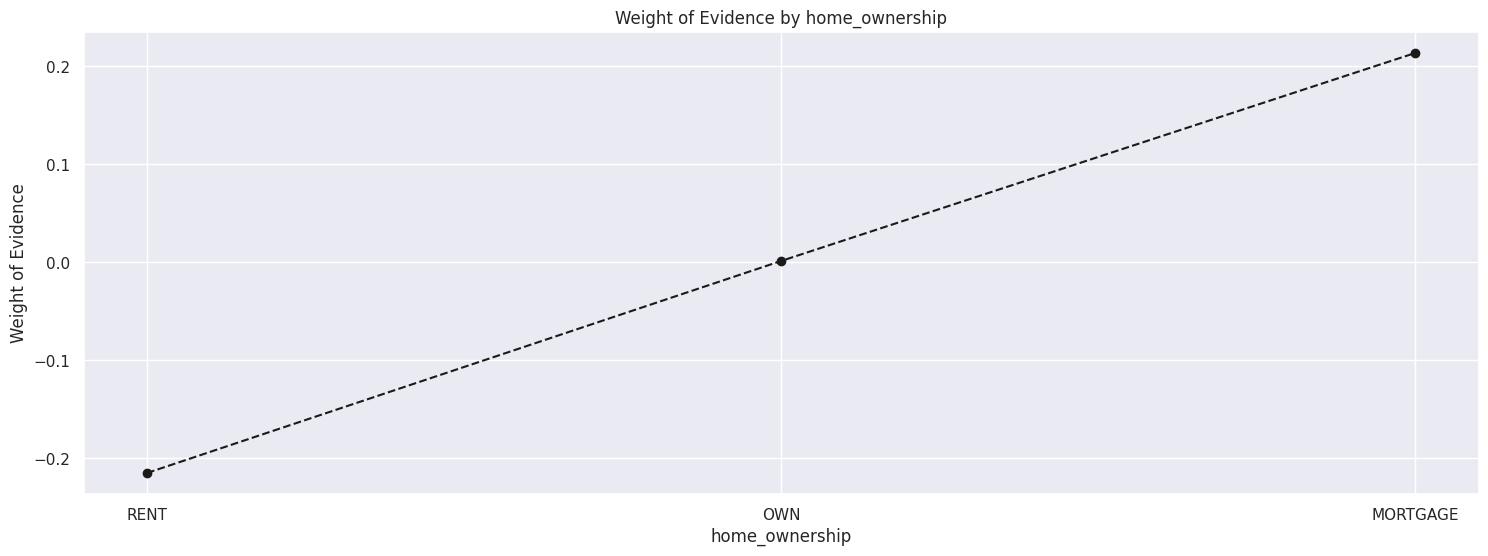

In [47]:
plot_by_woe(df_temp)

In [48]:
df_temp = woe_discrete(X_train_prepr, 'verification_status', y_train_prepr)
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,98338,0.976632,0.291912,96040.0,2298.0,0.290507,0.365865,-0.230636,NaN,NaN,0.046138
1,Source Verified,143639,0.981036,0.426387,140915.0,2724.0,0.426248,0.433689,-0.017306,0.004404,0.213330,0.046138
2,Not Verified,94898,0.986733,0.281701,93639.0,1259.0,0.283245,0.200446,0.345767,0.005697,0.363074,0.046138


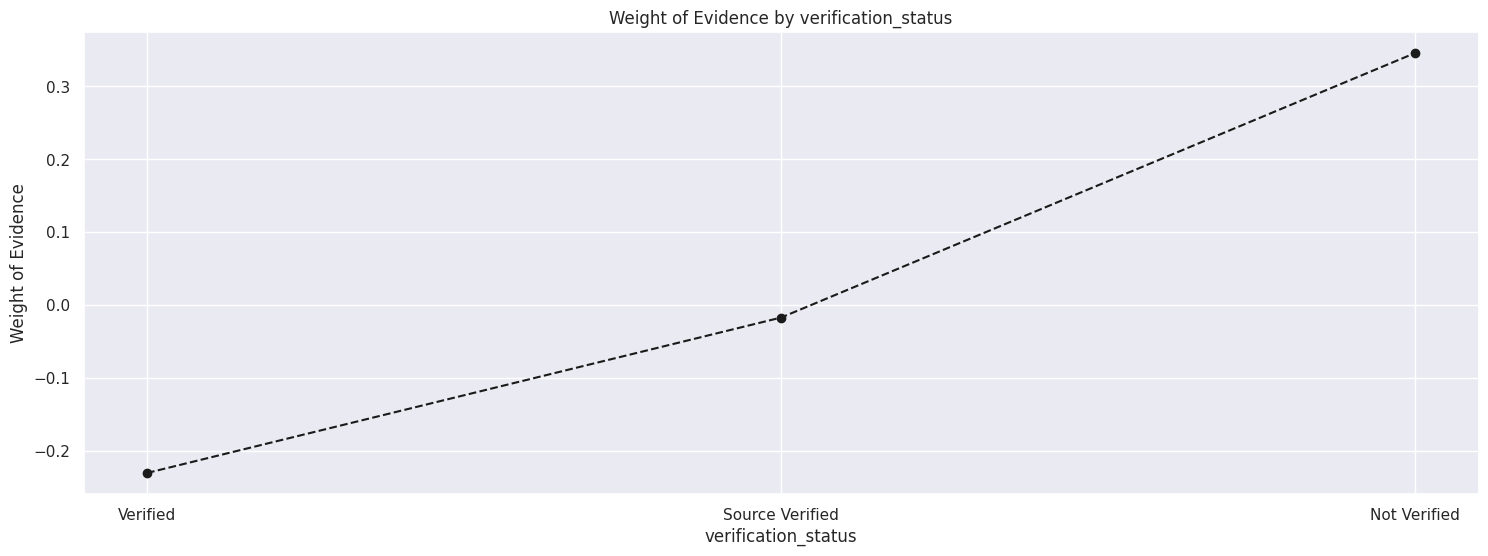

In [49]:
plot_by_woe(df_temp)

In [50]:
df_temp = woe_discrete(X_train_prepr, 'purpose', y_train_prepr)
df_temp

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,wedding,3,0.666667,0.000009,2.0,1.0,0.000006,0.000159,-3.270215,NaN,NaN,inf
1,renewable_energy,182,0.961538,0.000540,175.0,7.0,0.000529,0.001114,-0.744486,0.294872,2.525729,inf
2,small_business,2705,0.961553,0.008030,2601.0,104.0,0.007868,0.016558,-0.744101,0.000014,0.000385,inf
3,moving,1935,0.963824,0.005744,1865.0,70.0,0.005641,0.011145,-0.680841,0.002272,0.063261,inf
4,house,1146,0.972077,0.003402,1114.0,32.0,0.003370,0.005095,-0.413385,0.008252,0.267455,inf
5,medical,3179,0.972318,0.009437,3091.0,88.0,0.009350,0.014011,-0.404449,0.000242,0.008937,inf
6,major_purchase,5974,0.975561,0.017734,5828.0,146.0,0.017629,0.023245,-0.276539,0.003242,0.127909,inf
7,other,15428,0.977120,0.045797,15075.0,353.0,0.045600,0.056201,-0.209037,0.001559,0.067502,inf
8,vacation,1769,0.979650,0.005251,1733.0,36.0,0.005242,0.005732,-0.089271,0.002530,0.119765,inf
9,debt_consolidation,199960,0.979761,0.593573,195913.0,4047.0,0.592609,0.644324,-0.083667,0.000111,0.005604,inf


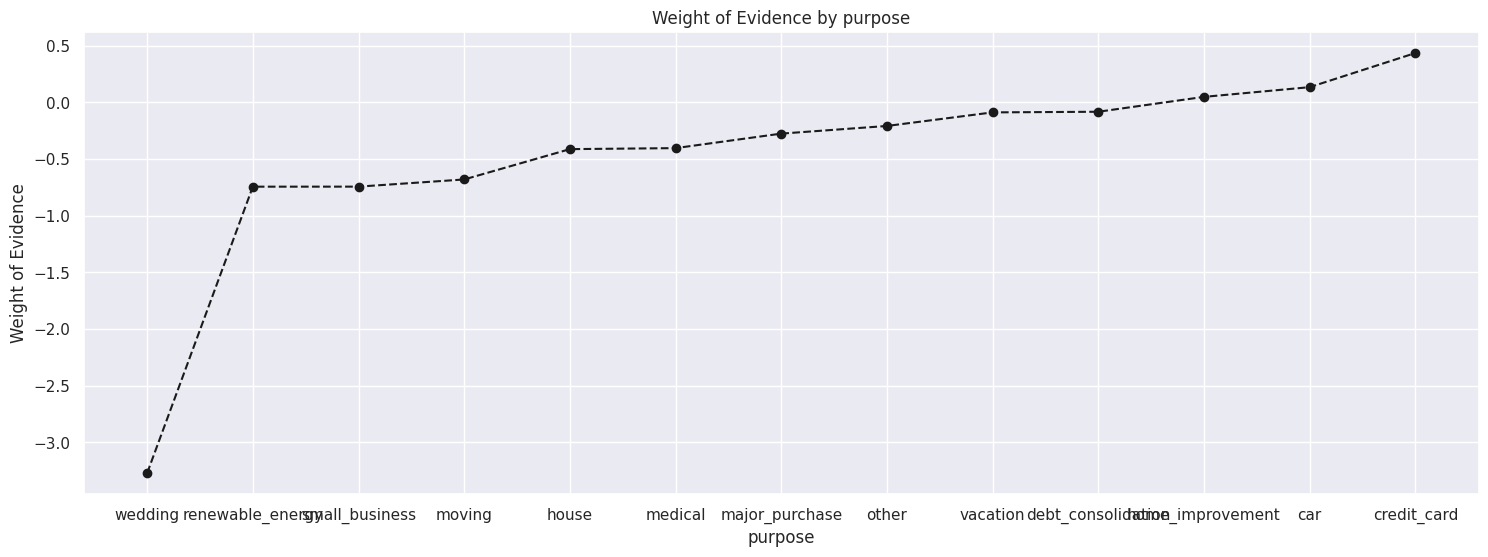

In [51]:
plot_by_woe(df_temp)

In [52]:
X_train_prepr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336875 entries, 304531 to 312076
Data columns (total 61 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            336875 non-null  int64  
 1   term                                 336875 non-null  int64  
 2   int_rate                             336875 non-null  float64
 3   installment                          336875 non-null  float64
 4   grade                                336875 non-null  object 
 5   emp_length                           336875 non-null  float64
 6   home_ownership                       336875 non-null  object 
 7   annual_inc                           336875 non-null  float64
 8   verification_status                  336875 non-null  object 
 9   purpose                              336875 non-null  object 
 10  dti                                  336875 non-null  float64
 11  delinq_2yrs  

In [53]:
# We define a function to calculate WoE of continuous variables. This is same as the function we defined earlier for discrete variables.
# The only difference are the 2 commented lines of code in the function that results in the df being sorted by continuous variable values
def woe_ordered_continuous(df, continuous_variabe_name, y_df):
    df = pd.concat([df[continuous_variabe_name], y_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    #df = df.sort_values(['WoE'])
    #df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [54]:
df_temp = woe_ordered_continuous(X_train_prepr, 'term', y_train_prepr)
df_temp

,term,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,226487,0.983434,0.672318,222735.0,3752.0,0.673742,0.597357,0.120332,NaN,NaN,0.02526
1,60,110388,0.977090,0.327682,107859.0,2529.0,0.326258,0.402643,-0.210361,0.006344,0.330693,0.02526


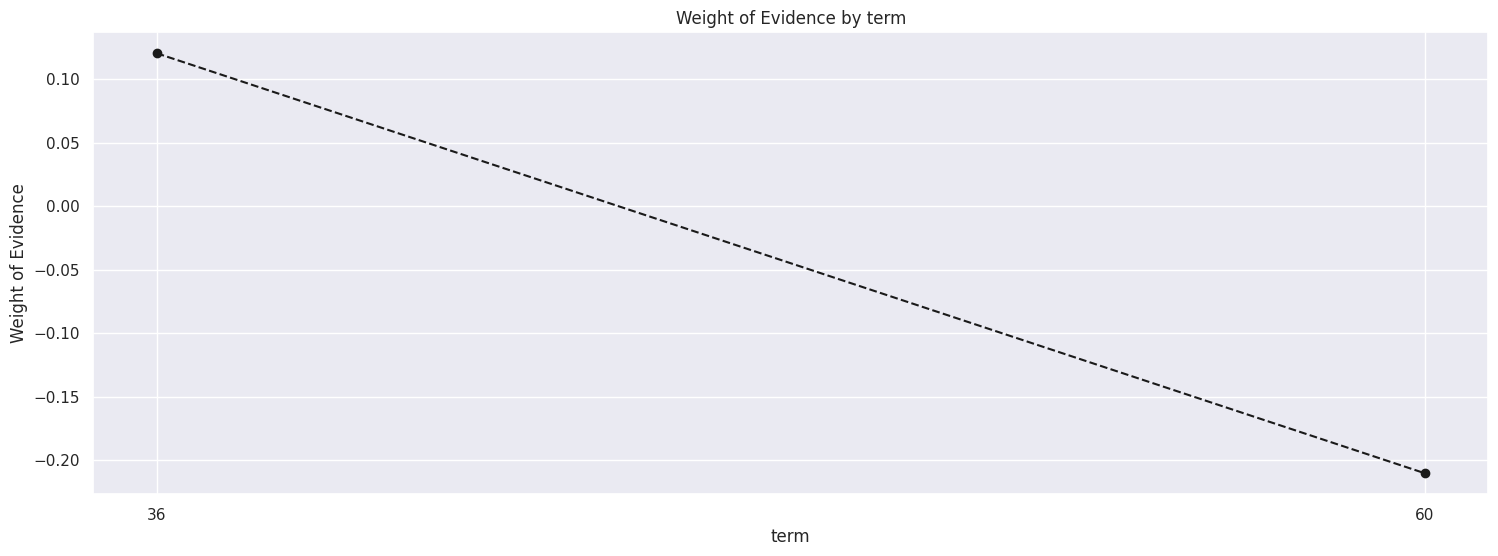

In [55]:
plot_by_woe(df_temp)

In [56]:
# fine-classing using the 'cut' method, given the large number of unique values
X_train_prepr['int_rate_factor'] = pd.cut(X_train_prepr['int_rate'], 50)
# Process 'int_rate_factor' column through woe_ordered_continuous and plot_by_woe functions
df_temp = woe_ordered_continuous(X_train_prepr, 'int_rate_factor', y_train_prepr)
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,int_rate_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(5.296, 5.793]",7803,0.999616,0.023163,7800.0,3.0,0.023594,0.000478,3.899905,NaN,NaN,inf
1,"(5.793, 6.267]",8159,0.997671,0.024220,8140.0,19.0,0.024622,0.003025,2.096745,0.001944,1.803160,inf
2,"(6.267, 6.74]",5249,0.993904,0.015581,5217.0,32.0,0.015781,0.005095,1.130580,0.003768,0.966165,inf
3,"(6.74, 7.214]",9956,0.995380,0.029554,9910.0,46.0,0.029976,0.007324,1.409296,0.001476,0.278716,inf
4,"(7.214, 7.687]",9068,0.997905,0.026918,9049.0,19.0,0.027372,0.003025,2.202609,0.002525,0.793312,inf
5,"(7.687, 8.16]",16496,0.995938,0.048968,16429.0,67.0,0.049695,0.010667,1.538749,0.001966,0.663860,inf
6,"(8.16, 8.634]",17998,0.993944,0.053426,17889.0,109.0,0.054112,0.017354,1.137232,0.001995,0.401517,inf
7,"(8.634, 9.107]",1596,0.981203,0.004738,1566.0,30.0,0.004737,0.004776,-0.008279,0.012741,1.145511,inf
8,"(9.107, 9.581]",17763,0.992625,0.052729,17632.0,131.0,0.053334,0.020857,0.938912,0.011422,0.947191,inf
9,"(9.581, 10.054]",17811,0.993543,0.052871,17696.0,115.0,0.053528,0.018309,1.072800,0.000918,0.133888,inf


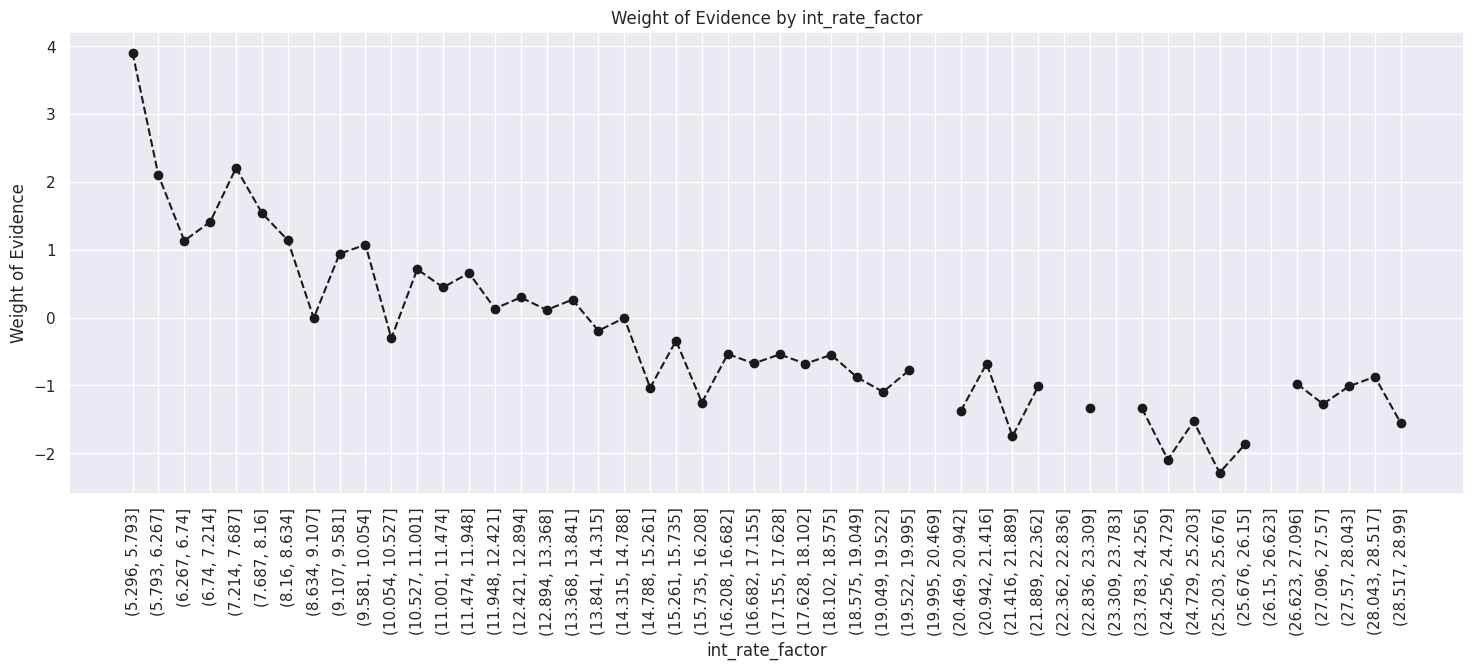

In [57]:
plot_by_woe(df_temp, 90)

In [58]:
df_temp = woe_ordered_continuous(X_train_prepr, 'emp_length', y_train_prepr)
df_temp

,emp_length,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,46622,0.978015,0.138396,45597.0,1025.0,0.137924,0.163191,-0.168213,NaN,NaN,0.018411
1,1.0,21900,0.978219,0.065009,21423.0,477.0,0.064802,0.075943,-0.158658,0.000205,0.009555,0.018411
2,2.0,30073,0.980680,0.089271,29492.0,581.0,0.089209,0.092501,-0.036238,0.002461,0.122420,0.018411
3,3.0,26659,0.981095,0.079136,26155.0,504.0,0.079115,0.080242,-0.014142,0.000414,0.022096,0.018411
4,4.0,19663,0.979301,0.058369,19256.0,407.0,0.058247,0.064799,-0.106597,0.001793,0.092455,0.018411
5,5.0,19918,0.981123,0.059126,19542.0,376.0,0.059112,0.059863,-0.012630,0.001821,0.093967,0.018411
6,6.0,13555,0.978975,0.040237,13270.0,285.0,0.040140,0.045375,-0.122590,0.002148,0.109960,0.018411
7,7.0,14735,0.978215,0.043740,14414.0,321.0,0.043600,0.051107,-0.158848,0.000759,0.036258,0.018411
8,8.0,17211,0.984080,0.051090,16937.0,274.0,0.051232,0.043624,0.160766,0.005865,0.319614,0.018411
9,9.0,13430,0.982427,0.039866,13194.0,236.0,0.039910,0.037574,0.060324,0.001653,0.100442,0.018411


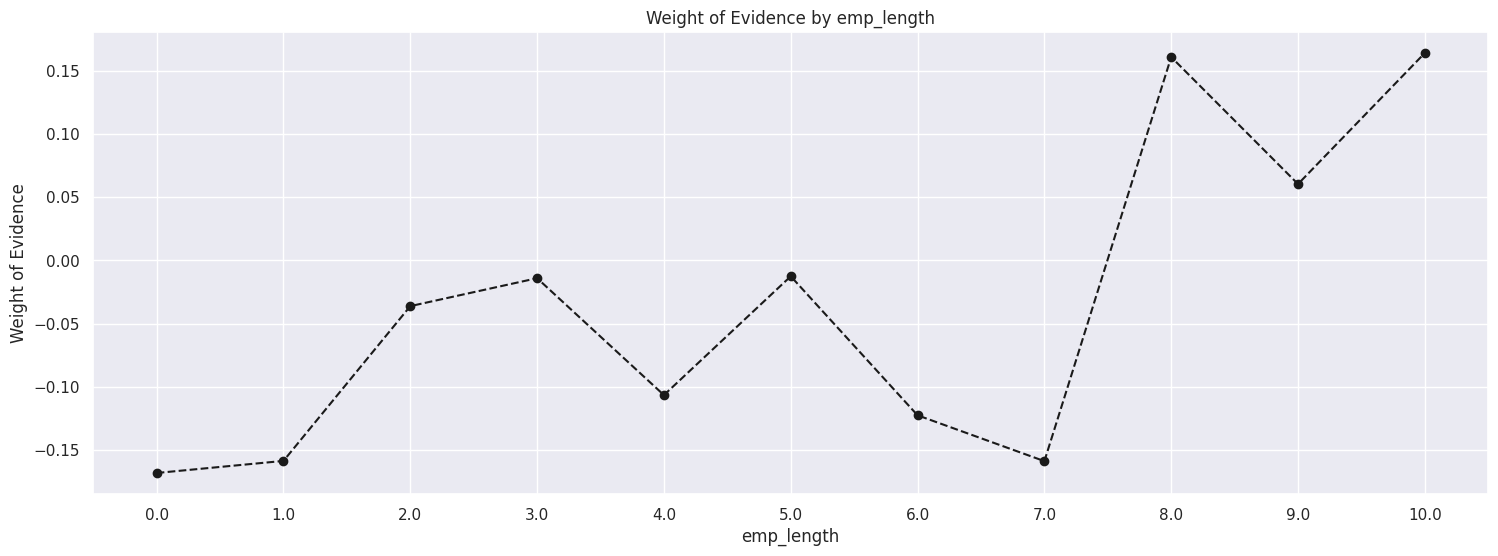

In [60]:
plot_by_woe(df_temp)

In [61]:
# Initial examination shows that there are too few individuals with large income (up to $75m!!) and too many with small income.
# Since 95.6% of observations have income < 151,858, we will have one category for more than 150K, and we are going to apply our approach to determine
# the categories of everyone with 150k or less.
X_train_prepr_temp = X_train_prepr[X_train_prepr['annual_inc'] <= 150000].copy()
# fine-classing again
X_train_prepr_temp['annual_inc_factor'] = pd.cut(X_train_prepr_temp['annual_inc'], 50)
# make sure to select only the relevant indexes in the target column
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'annual_inc_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-150.0, 3000.0]",5,1.000000,0.000016,5.0,0.0,0.000016,0.000000,inf,NaN,NaN,inf
1,"(3000.0, 6000.0]",14,0.928571,0.000044,13.0,1.0,0.000042,0.000166,-1.384886,0.071429,inf,inf
2,"(6000.0, 9000.0]",87,0.988506,0.000273,86.0,1.0,0.000275,0.000166,0.504512,0.059934,1.889398,inf
3,"(9000.0, 12000.0]",524,0.971374,0.001644,509.0,15.0,0.001627,0.002490,-0.425437,0.017132,0.929949,inf
4,"(12000.0, 15000.0]",944,0.975636,0.002961,921.0,23.0,0.002944,0.003818,-0.259869,0.004262,0.165568,inf
5,"(15000.0, 18000.0]",1375,0.970182,0.004313,1334.0,41.0,0.004265,0.006806,-0.467470,0.005454,0.207601,inf
6,"(18000.0, 21000.0]",2511,0.971724,0.007876,2440.0,71.0,0.007800,0.011786,-0.412761,0.001543,0.054708,inf
7,"(21000.0, 24000.0]",3540,0.974859,0.011103,3451.0,89.0,0.011032,0.014774,-0.292052,0.003134,0.120710,inf
8,"(24000.0, 27000.0]",5431,0.974222,0.017034,5291.0,140.0,0.016915,0.023240,-0.317715,0.000637,0.025663,inf
9,"(27000.0, 30000.0]",8825,0.975071,0.027679,8605.0,220.0,0.027509,0.036521,-0.283364,0.000849,0.034351,inf


In [62]:
# Initial examination shows that there are too few individuals with large income (up to $75m!!) and too many with small income.
# Since 95.6% of observations have income < 151,858, we will have one category for more than 150K, and we are going to apply our approach to determine
# the categories of everyone with 150k or less.
X_train_prepr_temp = X_train_prepr[X_train_prepr['annual_inc'] <= 150000].copy()
# fine-classing again
X_train_prepr_temp['annual_inc_factor'] = pd.cut(X_train_prepr_temp['annual_inc'], 50)
# make sure to select only the relevant indexes in the target column
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'annual_inc_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-150.0, 3000.0]",5,1.000000,0.000016,5.0,0.0,0.000016,0.000000,inf,NaN,NaN,inf
1,"(3000.0, 6000.0]",14,0.928571,0.000044,13.0,1.0,0.000042,0.000166,-1.384886,0.071429,inf,inf
2,"(6000.0, 9000.0]",87,0.988506,0.000273,86.0,1.0,0.000275,0.000166,0.504512,0.059934,1.889398,inf
3,"(9000.0, 12000.0]",524,0.971374,0.001644,509.0,15.0,0.001627,0.002490,-0.425437,0.017132,0.929949,inf
4,"(12000.0, 15000.0]",944,0.975636,0.002961,921.0,23.0,0.002944,0.003818,-0.259869,0.004262,0.165568,inf
5,"(15000.0, 18000.0]",1375,0.970182,0.004313,1334.0,41.0,0.004265,0.006806,-0.467470,0.005454,0.207601,inf
6,"(18000.0, 21000.0]",2511,0.971724,0.007876,2440.0,71.0,0.007800,0.011786,-0.412761,0.001543,0.054708,inf
7,"(21000.0, 24000.0]",3540,0.974859,0.011103,3451.0,89.0,0.011032,0.014774,-0.292052,0.003134,0.120710,inf
8,"(24000.0, 27000.0]",5431,0.974222,0.017034,5291.0,140.0,0.016915,0.023240,-0.317715,0.000637,0.025663,inf
9,"(27000.0, 30000.0]",8825,0.975071,0.027679,8605.0,220.0,0.027509,0.036521,-0.283364,0.000849,0.034351,inf


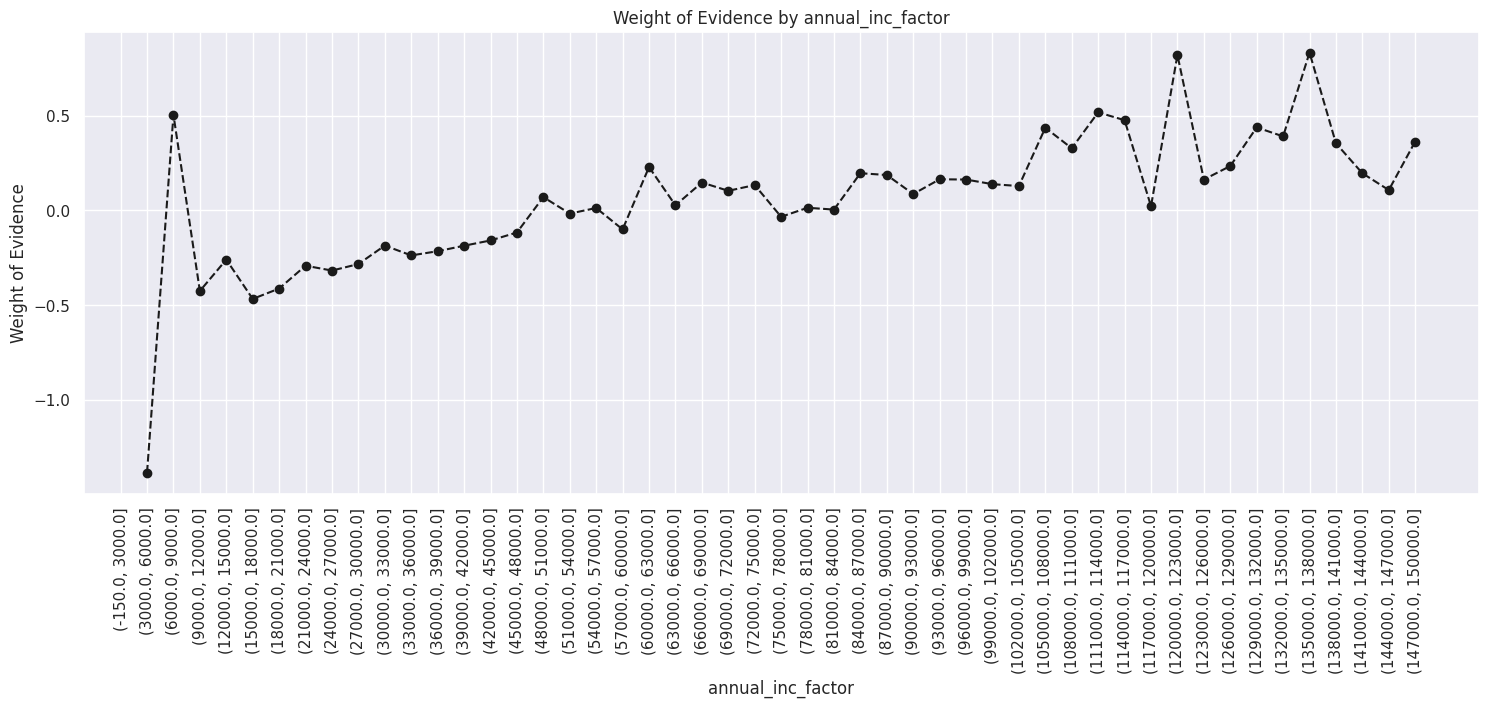

In [63]:
plot_by_woe(df_temp, 90)

In [64]:
X_train_prepr_temp = X_train_prepr[X_train_prepr['dti'] <= 42].copy()
# fine-classing
X_train_prepr_temp['dti_factor'] = pd.cut(X_train_prepr_temp['dti'], 50)
# Process 'annual_inc_factor' column through woe_ordered_continuous and plot_by_woe functions
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'dti_factor', y_train_prepr)
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.0419, 0.839]",715,0.974825,0.002123,697.0,18.0,0.002109,0.002866,-0.306779,NaN,NaN,inf
1,"(0.839, 1.678]",1176,0.983844,0.003491,1157.0,19.0,0.003500,0.003025,0.145954,0.009018,0.452733,inf
2,"(1.678, 2.516]",1758,0.982935,0.005219,1728.0,30.0,0.005228,0.004776,0.090330,0.000908,0.055624,inf
3,"(2.516, 3.355]",2532,0.983017,0.007517,2489.0,43.0,0.007530,0.006846,0.095244,0.000082,0.004914,inf
4,"(3.355, 4.194]",3263,0.984064,0.009688,3211.0,52.0,0.009714,0.008279,0.159902,0.001046,0.064658,inf
5,"(4.194, 5.033]",3872,0.987087,0.011496,3822.0,50.0,0.011563,0.007961,0.373314,0.003023,0.213412,inf
6,"(5.033, 5.872]",4916,0.987185,0.014595,4853.0,63.0,0.014682,0.010030,0.381025,0.000098,0.007712,inf
7,"(5.872, 6.71]",5540,0.986462,0.016448,5465.0,75.0,0.016534,0.011941,0.325439,0.000723,0.055586,inf
8,"(6.71, 7.549]",6270,0.986284,0.018615,6184.0,86.0,0.018709,0.013692,0.312181,0.000178,0.013258,inf
9,"(7.549, 8.388]",7188,0.983445,0.021341,7069.0,119.0,0.021386,0.018946,0.121158,0.002839,0.191022,inf


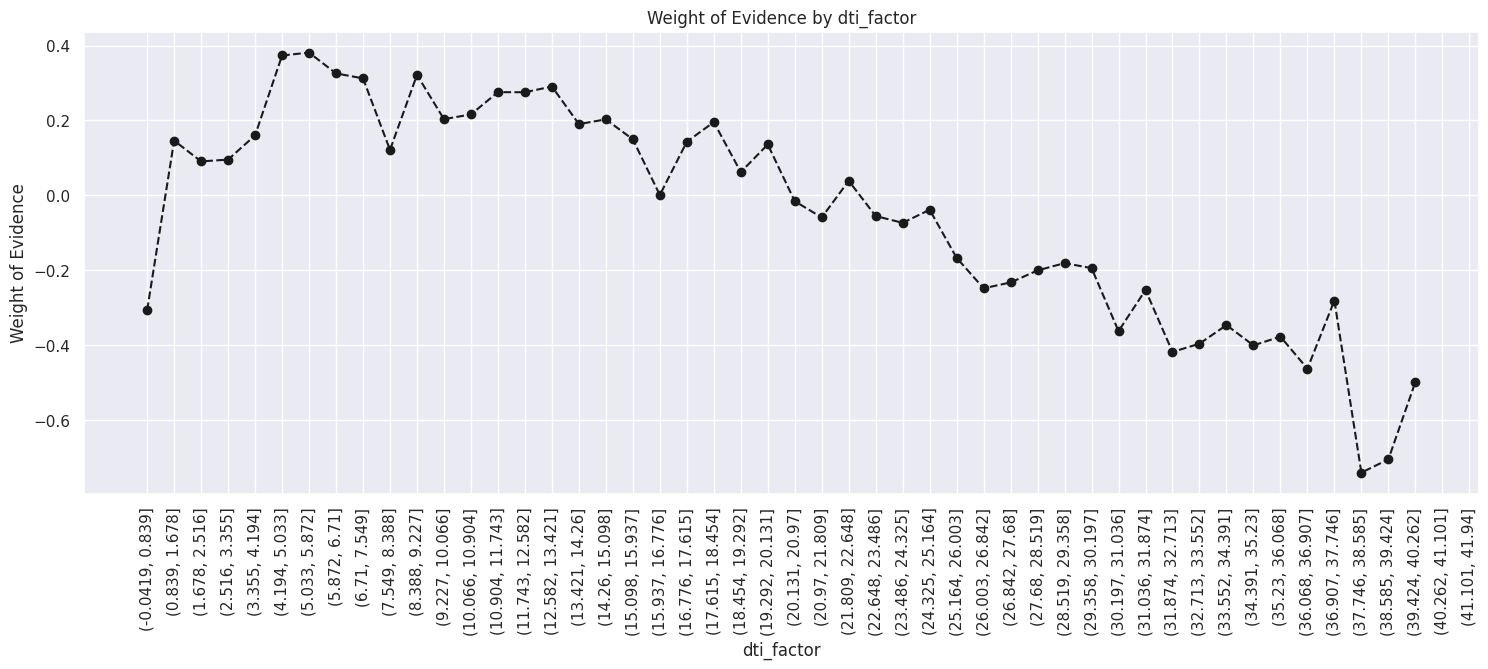

In [65]:
plot_by_woe(df_temp, 90)

In [66]:
df_temp = woe_ordered_continuous(X_train_prepr, 'inq_last_6mths', y_train_prepr)
df_temp

,inq_last_6mths,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0,205034,0.985002,0.608635,201959.0,3075.0,0.610897,0.489572,0.221398,NaN,NaN,0.074358
1,1,89056,0.978272,0.264359,87121.0,1935.0,0.263529,0.308072,-0.156171,0.006730,0.377569,0.074358
2,2,29108,0.973203,0.086406,28328.0,780.0,0.085688,0.124184,-0.371050,0.005069,0.214879,0.074358
3,3,9848,0.964968,0.029233,9503.0,345.0,0.028745,0.054928,-0.647543,0.008236,0.276494,0.074358
4,4,2818,0.965224,0.008365,2720.0,98.0,0.008228,0.015603,-0.639942,0.000256,0.007601,0.074358
5,5,980,0.953061,0.002909,934.0,46.0,0.002825,0.007324,-0.952527,0.012162,0.312585,0.074358
6,6,31,0.935484,0.000092,29.0,2.0,0.000088,0.000318,-1.289213,0.017577,0.336686,0.074358


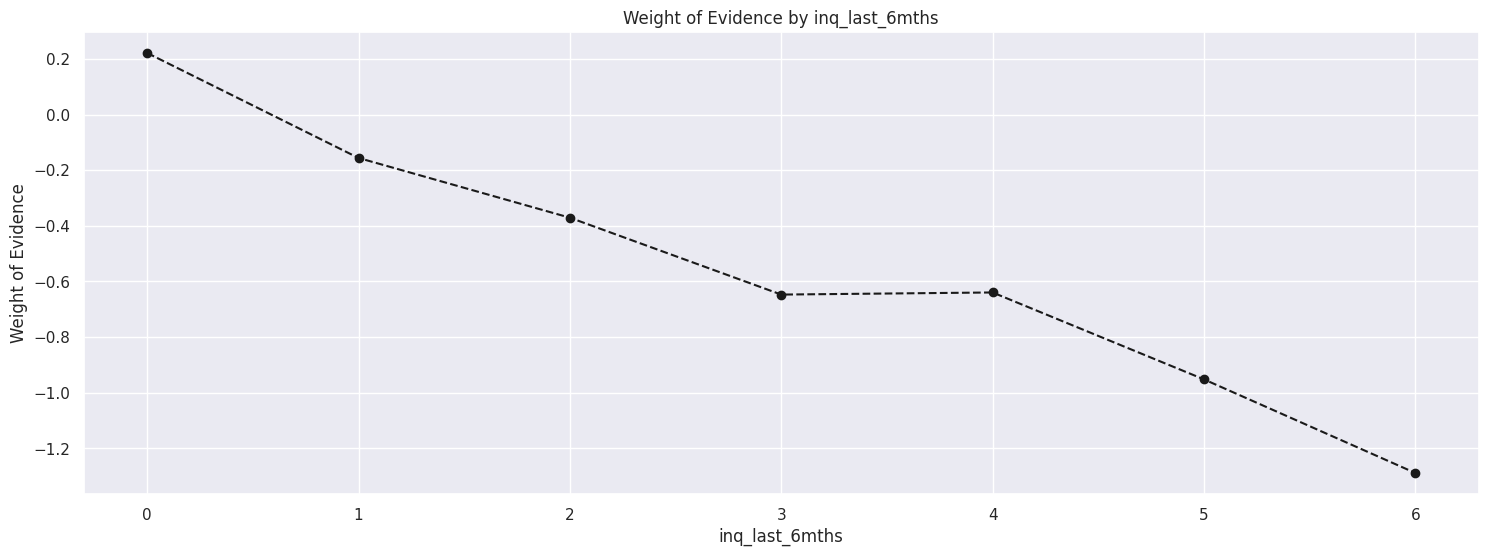

In [67]:
plot_by_woe(df_temp)

In [68]:
# Initial examination shows that there are some obs with utilization of >1 times which should be very rare, so we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['revol_util'] <= 1].copy()
# fine-classing
X_train_prepr_temp['revol_util_factor'] = pd.cut(X_train_prepr_temp['revol_util'], 10)
# preprocess 'revol_util'
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'revol_util_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,revol_util_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.001, 0.1]",1157,0.974935,0.582578,1128.0,29.0,0.582645,0.58,0.004549,NaN,NaN,0.056447
1,"(0.1, 0.2]",102,0.980392,0.051360,100.0,2.0,0.051653,0.04,0.255667,0.005457,0.251117,0.056447
2,"(0.2, 0.3]",107,0.981308,0.053877,105.0,2.0,0.054236,0.04,0.304457,0.000916,0.048790,0.056447
3,"(0.3, 0.4]",78,0.974359,0.039275,76.0,2.0,0.039256,0.04,-0.018770,0.006949,0.323227,0.056447
4,"(0.4, 0.5]",114,0.973684,0.057402,111.0,3.0,0.057335,0.06,-0.045438,0.000675,0.026668,0.056447
5,"(0.5, 0.6]",84,0.988095,0.042296,83.0,1.0,0.042872,0.02,0.762484,0.014411,0.807923,0.056447
6,"(0.6, 0.7]",84,0.964286,0.042296,81.0,3.0,0.041839,0.06,-0.360519,0.023810,1.123004,0.056447
7,"(0.7, 0.8]",91,0.967033,0.045821,88.0,3.0,0.045455,0.06,-0.277632,0.002747,0.082888,0.056447
8,"(0.8, 0.9]",67,0.985075,0.033736,66.0,1.0,0.034091,0.02,0.533298,0.018042,0.810930,0.056447
9,"(0.9, 1.0]",102,0.960784,0.051360,98.0,4.0,0.050620,0.08,-0.457683,0.024290,0.990982,0.056447


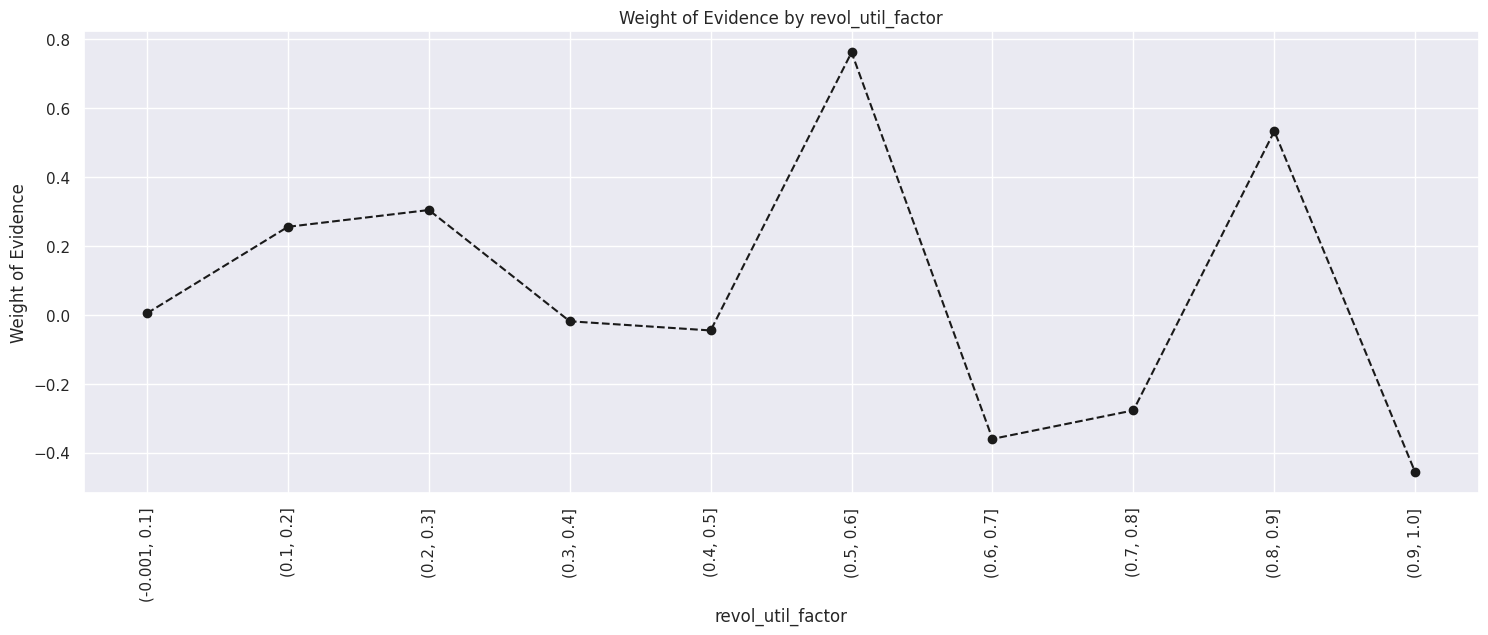

In [69]:
plot_by_woe(df_temp, 90)

In [70]:
# Initial examination shows that there are some obs >50 accounts which should be very rare, so we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['total_acc'] <= 50].copy()
# fine-classing
X_train_prepr_temp['total_acc_factor'] = pd.cut(X_train_prepr_temp['total_acc'], 20)
# preprocess 'total_acc'
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'total_acc_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(3.954, 6.3]",5475,0.978447,0.016869,5357.0,118.0,0.016819,0.019494,-0.147625,NaN,NaN,0.006664
1,"(6.3, 8.6]",8097,0.977893,0.024947,7918.0,179.0,0.024860,0.029572,-0.173592,0.000554,0.025967,0.006664
2,"(8.6, 10.9]",12179,0.980622,0.037524,11943.0,236.0,0.037496,0.038989,-0.039031,0.002729,0.134561,0.006664
3,"(10.9, 13.2]",25201,0.979604,0.077646,24687.0,514.0,0.077508,0.084917,-0.091291,0.001018,0.052260,0.006664
4,"(13.2, 15.5]",20233,0.980082,0.062339,19830.0,403.0,0.062259,0.066579,-0.067085,0.000478,0.024206,0.006664
5,"(15.5, 17.8]",22381,0.980072,0.068957,21935.0,446.0,0.068868,0.073682,-0.067580,0.000010,0.000495,0.006664
6,"(17.8, 20.1]",35721,0.982559,0.110059,35098.0,623.0,0.110194,0.102924,0.068253,0.002487,0.135833,0.006664
7,"(20.1, 22.4]",24194,0.982392,0.074543,23768.0,426.0,0.074622,0.070378,0.058556,0.000167,0.009697,0.006664
8,"(22.4, 24.7]",23343,0.980808,0.071921,22895.0,448.0,0.071882,0.074013,-0.029219,0.001584,0.087775,0.006664
9,"(24.7, 27.0]",32718,0.981111,0.100806,32100.0,618.0,0.100782,0.102098,-0.012977,0.000303,0.016242,0.006664


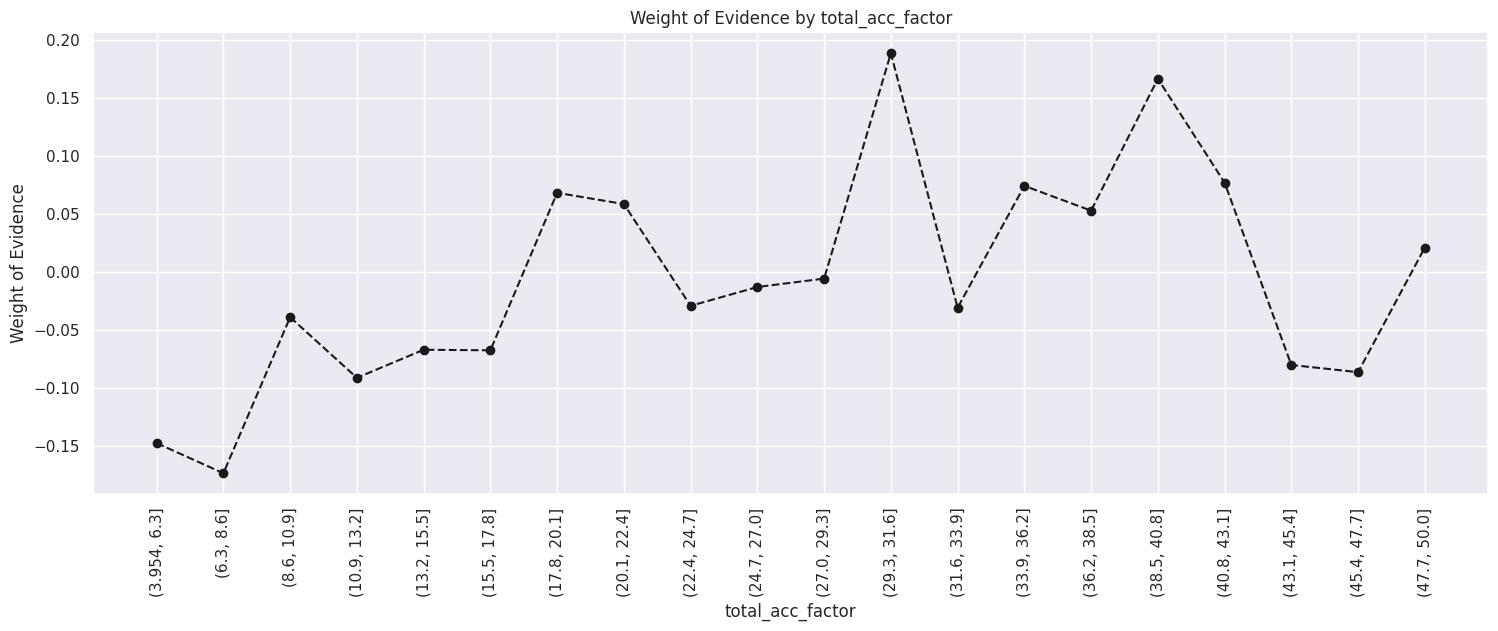

In [71]:
plot_by_woe(df_temp, 90)

In [72]:
# Here we do fine-classing: using the 'cut' method, we split the variable into 25 categories by its values.
X_train_prepr['out_prncp_factor'] = pd.cut(X_train_prepr['out_prncp'], 25)
# We calculate weight of evidence.
df_temp = woe_ordered_continuous(X_train_prepr, 'out_prncp_factor', y_train_prepr)
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,out_prncp_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-49.373, 1974.914]",26482,0.912167,0.078611,24156.0,2326.0,0.073068,0.370323,-1.622979,NaN,NaN,inf
1,"(1974.914, 3949.829]",18014,0.989286,0.053474,17821.0,193.0,0.053906,0.030728,0.562081,0.077119,2.185060,inf
2,"(3949.829, 5924.743]",32464,0.988295,0.096368,32084.0,380.0,0.097050,0.060500,0.472580,0.000991,0.089501,inf
3,"(5924.743, 7899.658]",30677,0.988265,0.091063,30317.0,360.0,0.091705,0.057316,0.469998,0.000030,0.002582,inf
4,"(7899.658, 9874.572]",35435,0.987611,0.105187,34996.0,439.0,0.105858,0.069893,0.415128,0.000654,0.054870,inf
5,"(9874.572, 11849.486]",32265,0.985991,0.095777,31813.0,452.0,0.096230,0.071963,0.290586,0.001620,0.124542,inf
6,"(11849.486, 13824.401]",25678,0.985747,0.076224,25312.0,366.0,0.076565,0.058271,0.273039,0.000244,0.017548,inf
7,"(13824.401, 15799.315]",27362,0.988451,0.081223,27046.0,316.0,0.081810,0.050310,0.486190,0.002705,0.213152,inf
8,"(15799.315, 17774.23]",19514,0.987189,0.057927,19264.0,250.0,0.058271,0.039803,0.381171,0.001262,0.105020,inf
9,"(17774.23, 19749.144]",20833,0.986128,0.061842,20544.0,289.0,0.062143,0.046012,0.300536,0.001061,0.080635,inf


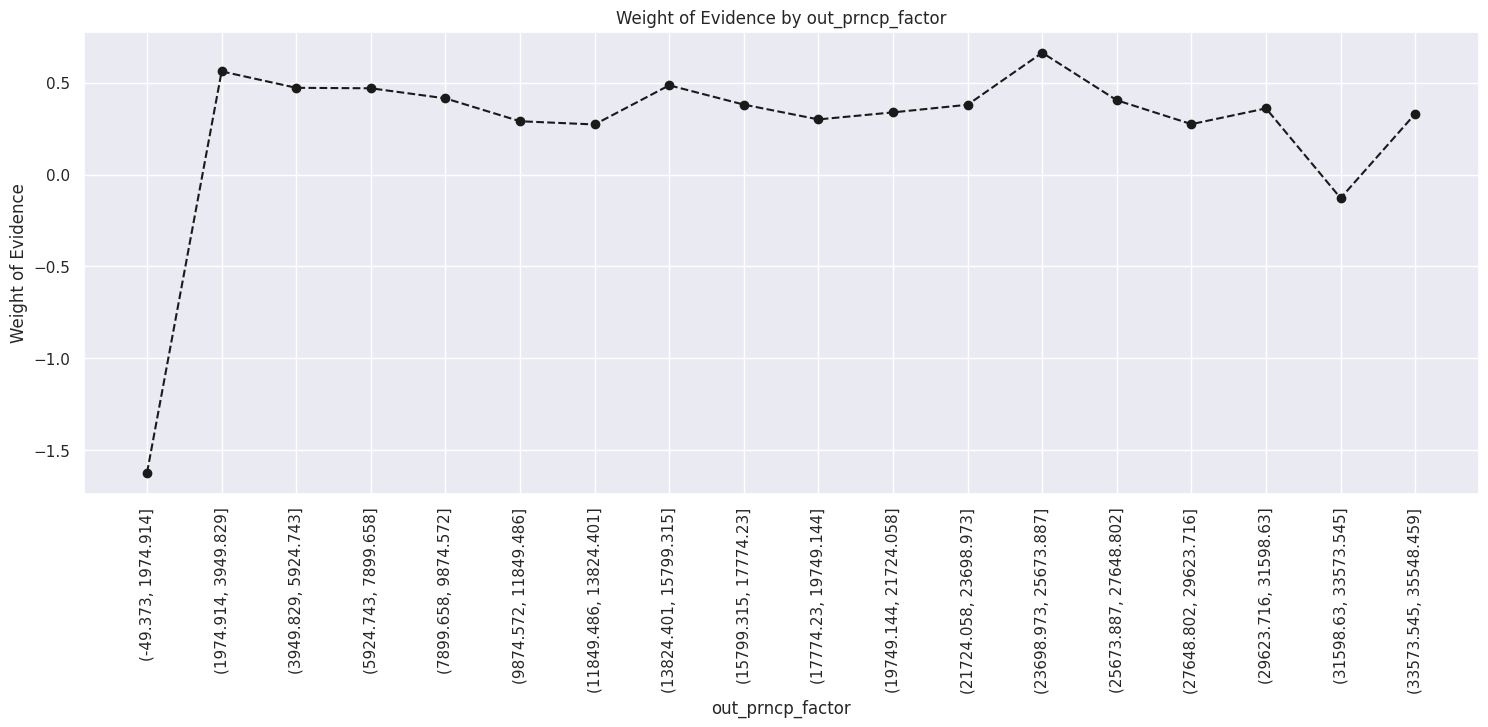

In [73]:
plot_by_woe(df_temp,90)

In [74]:
# Initial examination shows that there are vey few obs with >25,000 which should be very rare, so we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['total_pymnt'] <= 25000].copy()
# fine-classing
X_train_prepr_temp['total_pymnt_factor'] = pd.cut(X_train_prepr_temp['total_pymnt'], 20)
# preprocess 'total_acc'
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'total_pymnt_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,total_pymnt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-24.998, 1249.879]",117106,0.981880,0.350897,114984.0,2122.0,0.351142,0.338113,0.037810,NaN,NaN,inf
1,"(1249.879, 2499.758]",82038,0.976974,0.245819,80149.0,1889.0,0.244762,0.300988,-0.206784,0.004906,0.244594,inf
2,"(2499.758, 3749.637]",51843,0.979014,0.155343,50755.0,1088.0,0.154997,0.173359,-0.111955,0.002039,0.094829,inf
3,"(3749.637, 4999.516]",30202,0.980034,0.090497,29599.0,603.0,0.090390,0.096080,-0.061045,0.001021,0.050910,inf
4,"(4999.516, 6249.395]",18676,0.986025,0.055961,18415.0,261.0,0.056236,0.041587,0.301777,0.005990,0.362822,inf
5,"(6249.395, 7499.274]",10531,0.986136,0.031555,10385.0,146.0,0.031714,0.023263,0.309887,0.000111,0.008111,inf
6,"(7499.274, 8749.153]",6734,0.987229,0.020178,6648.0,86.0,0.020302,0.013703,0.393100,0.001093,0.083213,inf
7,"(8749.153, 9999.032]",3844,0.990375,0.011518,3807.0,37.0,0.011626,0.005895,0.679055,0.003146,0.285955,inf
8,"(9999.032, 11248.911]",3301,0.992729,0.009891,3277.0,24.0,0.010007,0.003824,0.962006,0.002355,0.282951,inf
9,"(11248.911, 12498.79]",1859,0.996235,0.005570,1852.0,7.0,0.005656,0.001115,1.623487,0.003505,0.661481,inf


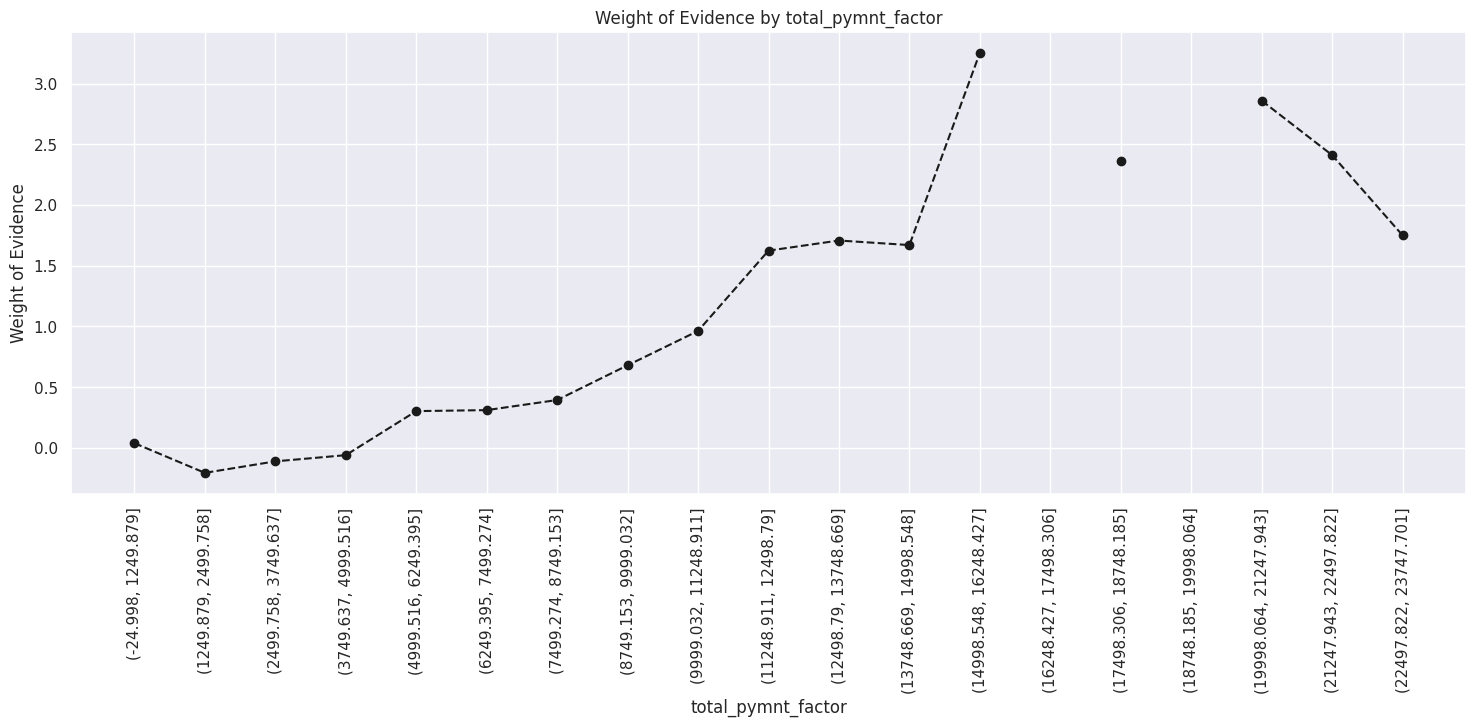

In [75]:
plot_by_woe(df_temp,90)

In [76]:
# Initial examination shows that there are vey few obs with >7,261 which should be very rare, so we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['total_rec_int'] <= 7261].copy()
# fine-classing
X_train_prepr_temp['total_rec_int_factor'] = pd.cut(X_train_prepr_temp['total_rec_int'], 20)
# preprocess 'total_rec_int'
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'total_rec_int_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,total_rec_int_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-7.257, 362.854]",126159,0.986026,0.374591,124396.0,1763.0,0.376376,0.280688,0.293345,NaN,NaN,0.055529
1,"(362.854, 725.707]",76866,0.981695,0.228231,75459.0,1407.0,0.228311,0.224009,0.019022,0.004330,0.274323,0.055529
2,"(725.707, 1088.56]",45860,0.978107,0.136168,44856.0,1004.0,0.135718,0.159847,-0.163642,0.003588,0.182664,0.055529
3,"(1088.56, 1451.414]",29096,0.976354,0.086392,28408.0,688.0,0.085952,0.109537,-0.242470,0.001753,0.078828,0.055529
4,"(1451.414, 1814.268]",19316,0.977998,0.057353,18891.0,425.0,0.057157,0.067664,-0.168756,0.001643,0.073714,0.055529
5,"(1814.268, 2177.121]",12702,0.972052,0.037715,12347.0,355.0,0.037357,0.056520,-0.414057,0.005946,0.245301,0.055529
6,"(2177.121, 2539.974]",8319,0.972713,0.024701,8092.0,227.0,0.024483,0.036141,-0.389427,0.000661,0.024631,0.055529
7,"(2539.974, 2902.828]",5608,0.977532,0.016651,5482.0,126.0,0.016586,0.020060,-0.190164,0.004819,0.199262,0.055529
8,"(2902.828, 3265.682]",3926,0.978859,0.011657,3843.0,83.0,0.011627,0.013214,-0.127940,0.001327,0.062225,0.055529
9,"(3265.682, 3628.535]",2786,0.976669,0.008272,2721.0,65.0,0.008233,0.010349,-0.228740,0.002190,0.100801,0.055529


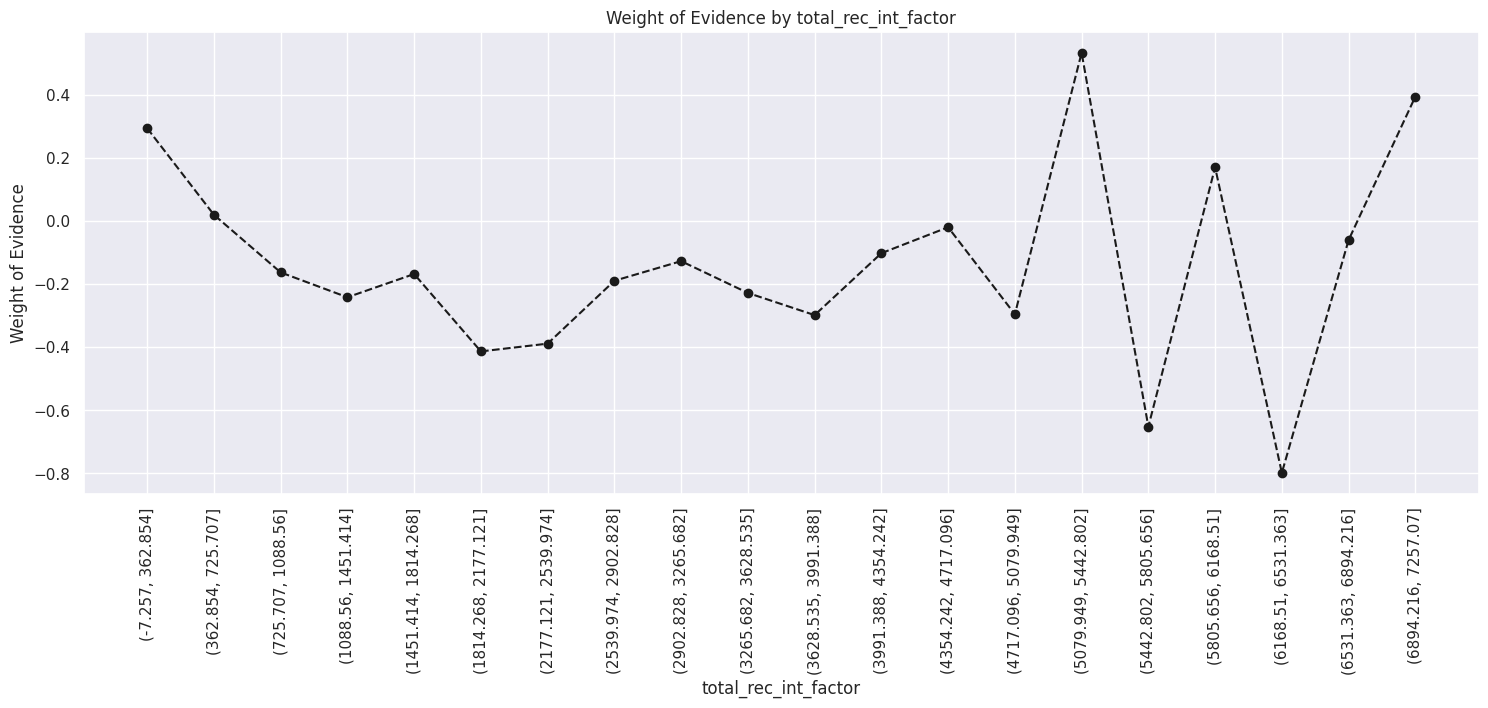

In [77]:
plot_by_woe(df_temp, 90)

In [78]:
# Initial examination shows that there are vey few obs with 10,000 which should be very rare, so we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['last_pymnt_amnt'] <= 10000].copy()
# fine-classing
X_train_prepr_temp['last_pymnt_amnt_factor'] = pd.cut(X_train_prepr_temp['last_pymnt_amnt'], 15)
# preprocess
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'last_pymnt_amnt_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,last_pymnt_amnt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-10.0, 666.667]",265031,0.980998,0.811110,259995.0,5036.0,0.811267,0.803062,0.010166,NaN,NaN,inf
1,"(666.667, 1333.333]",53782,0.977929,0.164596,52595.0,1187.0,0.164113,0.189284,-0.142692,0.003069,0.152858,inf
2,"(1333.333, 2000.0]",663,0.944193,0.002029,626.0,37.0,0.001953,0.005900,-1.105452,0.033736,0.962759,inf
3,"(2000.0, 2666.667]",510,0.990196,0.001561,505.0,5.0,0.001576,0.000797,0.681236,0.046003,1.786688,inf
4,"(2666.667, 3333.333]",473,0.995772,0.001448,471.0,2.0,0.001470,0.000319,1.527827,0.005576,0.846590,inf
5,"(3333.333, 4000.0]",522,0.998084,0.001598,521.0,1.0,0.001626,0.000159,2.321866,0.002313,0.794039,inf
6,"(4000.0, 4666.667]",581,1.000000,0.001778,581.0,0.0,0.001813,0.000000,inf,0.001916,inf,inf
7,"(4666.667, 5333.333]",768,0.998698,0.002350,767.0,1.0,0.002393,0.000159,2.708603,0.001302,inf,inf
8,"(5333.333, 6000.0]",673,0.998514,0.002060,672.0,1.0,0.002097,0.000159,2.576374,0.000184,0.132228,inf
9,"(6000.0, 6666.667]",668,1.000000,0.002044,668.0,0.0,0.002084,0.000000,inf,0.001486,inf,inf


In [79]:
# Again, because of very few obs > 64,000, we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['tot_cur_bal'] <= 80000].copy()
# fine-classing
X_train_prepr_temp['tot_cur_bal_factor'] = pd.cut(X_train_prepr_temp['tot_cur_bal'], 25)
# preprocess
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'tot_cur_bal_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,tot_cur_bal_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-80.0, 3200.0]",2492,0.978331,0.014763,2438.0,54.0,0.014760,0.014934,-0.011712,NaN,NaN,0.009755
1,"(3200.0, 6400.0]",6262,0.982114,0.037098,6150.0,112.0,0.037232,0.030973,0.184047,0.003784,0.195759,0.009755
2,"(6400.0, 9600.0]",7902,0.982663,0.046814,7765.0,137.0,0.047010,0.037887,0.215740,0.000548,0.031692,0.009755
3,"(9600.0, 12800.0]",9294,0.981063,0.055061,9118.0,176.0,0.055201,0.048673,0.125860,0.001600,0.089879,0.009755
4,"(12800.0, 16000.0]",9749,0.977331,0.057756,9528.0,221.0,0.057683,0.061117,-0.057834,0.003732,0.183694,0.009755
5,"(16000.0, 19200.0]",10357,0.978469,0.061358,10134.0,223.0,0.061352,0.061670,-0.005182,0.001138,0.052652,0.009755
6,"(19200.0, 22400.0]",10338,0.979300,0.061246,10124.0,214.0,0.061291,0.059181,0.035027,0.000831,0.040208,0.009755
7,"(22400.0, 25600.0]",10507,0.978205,0.062247,10278.0,229.0,0.062223,0.063330,-0.017622,0.001095,0.052649,0.009755
8,"(25600.0, 28800.0]",10195,0.978028,0.060399,9971.0,224.0,0.060365,0.061947,-0.025871,0.000177,0.008249,0.009755
9,"(28800.0, 32000.0]",9975,0.979248,0.059095,9768.0,207.0,0.059136,0.057246,0.032487,0.001220,0.058358,0.009755


In [80]:
# initial examination reveals very few obs > 79,780, we will filter them out first
X_train_prepr_temp = X_train_prepr[X_train_prepr['total_rev_hi_lim'] <= 79780].copy()
# fine-classing
X_train_prepr_temp['total_rev_hi_lim_factor'] = pd.cut(X_train_prepr_temp['total_rev_hi_lim'], 25)
# preprocess
df_temp = woe_ordered_continuous(X_train_prepr_temp, 'total_rev_hi_lim_factor', y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-79.755, 3190.2]",3834,0.970788,0.012161,3722.0,112.0,0.012037,0.018497,-0.429628,NaN,NaN,0.03953
1,"(3190.2, 6380.4]",14262,0.974337,0.045238,13896.0,366.0,0.044940,0.060446,-0.296423,0.003550,0.133205,0.03953
2,"(6380.4, 9570.6]",23512,0.975204,0.074578,22929.0,583.0,0.074153,0.096284,-0.261175,0.000867,0.035248,0.03953
3,"(9570.6, 12760.8]",27989,0.976955,0.088778,27344.0,645.0,0.088431,0.106524,-0.186144,0.001751,0.075032,0.03953
4,"(12760.8, 15951.0]",29375,0.978689,0.093175,28749.0,626.0,0.092975,0.103386,-0.106138,0.001734,0.080006,0.03953
5,"(15951.0, 19141.2]",28121,0.978664,0.089197,27521.0,600.0,0.089003,0.099092,-0.107371,0.000026,0.001233,0.03953
6,"(19141.2, 22331.4]",25538,0.981087,0.081004,25055.0,483.0,0.081028,0.079769,0.015666,0.002423,0.123037,0.03953
7,"(22331.4, 25521.6]",22592,0.982383,0.071660,22194.0,398.0,0.071776,0.065731,0.087979,0.001296,0.072313,0.03953
8,"(25521.6, 28711.8]",19978,0.982681,0.063368,19632.0,346.0,0.063490,0.057143,0.105331,0.000298,0.017352,0.03953
9,"(28711.8, 31902.0]",17404,0.982418,0.055204,17098.0,306.0,0.055295,0.050537,0.089986,0.000263,0.015346,0.03953


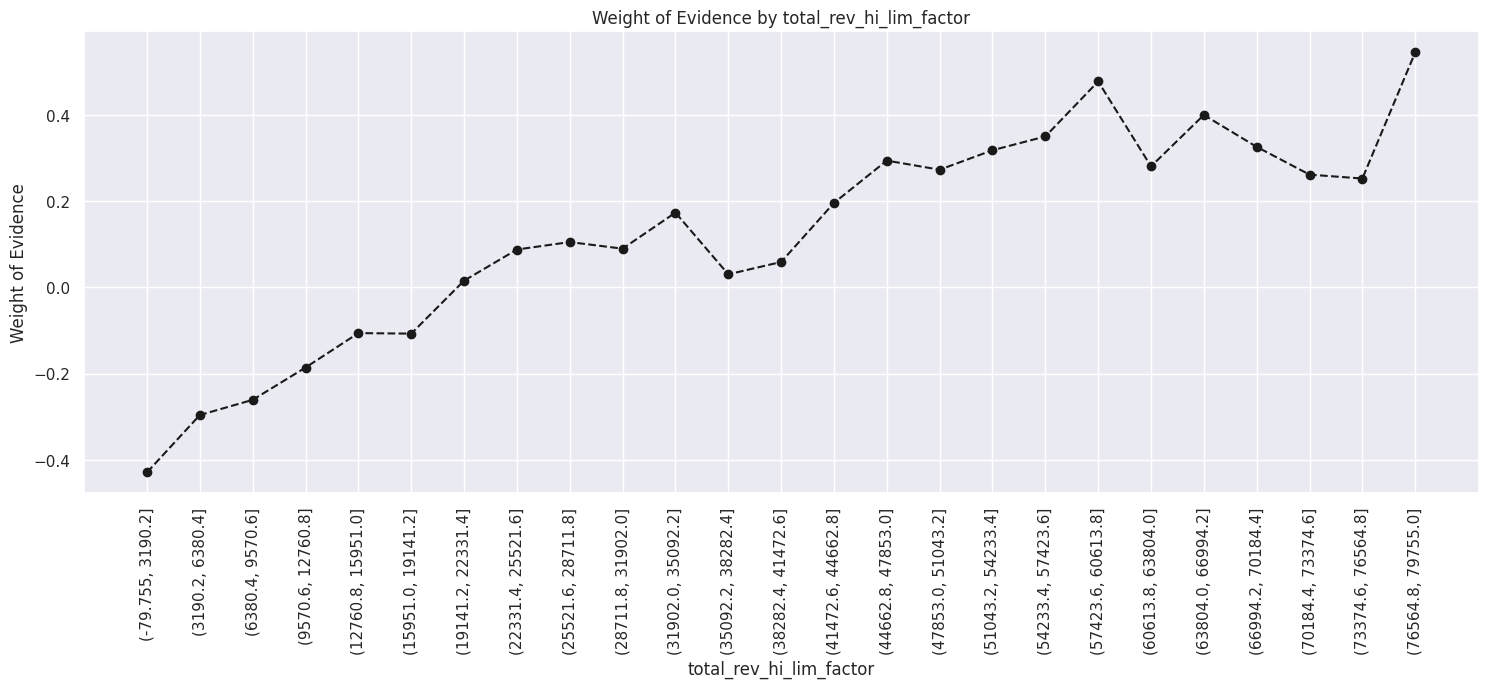

In [81]:
plot_by_woe(df_temp, 90)

In [82]:
# fine-classing
X_train_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(X_train_prepr['mths_since_earliest_cr_line'], 25)
# preprocess
df_temp = woe_ordered_continuous(X_train_prepr, 'mths_since_earliest_cr_line_factor', y_train_prepr)
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_earliest_cr_line_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(92.474, 114.04]",5514,0.977512,0.016368,5390.0,124.0,0.016304,0.019742,-0.191343,NaN,NaN,0.03635
1,"(114.04, 135.08]",8005,0.975016,0.023763,7805.0,200.0,0.023609,0.031842,-0.299159,0.002496,0.107817,0.03635
2,"(135.08, 156.12]",13109,0.974445,0.038914,12774.0,335.0,0.038640,0.053335,-0.322325,0.000571,0.023166,0.03635
3,"(156.12, 177.16]",21410,0.975199,0.063555,20879.0,531.0,0.063156,0.084541,-0.291625,0.000753,0.030701,0.03635
4,"(177.16, 198.2]",34212,0.977990,0.101557,33459.0,753.0,0.101209,0.119885,-0.169351,0.002792,0.122274,0.03635
5,"(198.2, 219.24]",39692,0.979920,0.117824,38895.0,797.0,0.117652,0.126891,-0.075596,0.001930,0.093755,0.03635
6,"(219.24, 240.28]",40345,0.981361,0.119763,39593.0,752.0,0.119763,0.119726,0.000309,0.001440,0.075905,0.03635
7,"(240.28, 261.32]",33641,0.981481,0.099862,33018.0,623.0,0.099875,0.099188,0.006900,0.000120,0.006590,0.03635
8,"(261.32, 282.36]",26639,0.983220,0.079077,26192.0,447.0,0.079227,0.071167,0.107289,0.001739,0.100389,0.03635
9,"(282.36, 303.4]",24283,0.983898,0.072083,23892.0,391.0,0.072270,0.062251,0.149230,0.000678,0.041941,0.03635


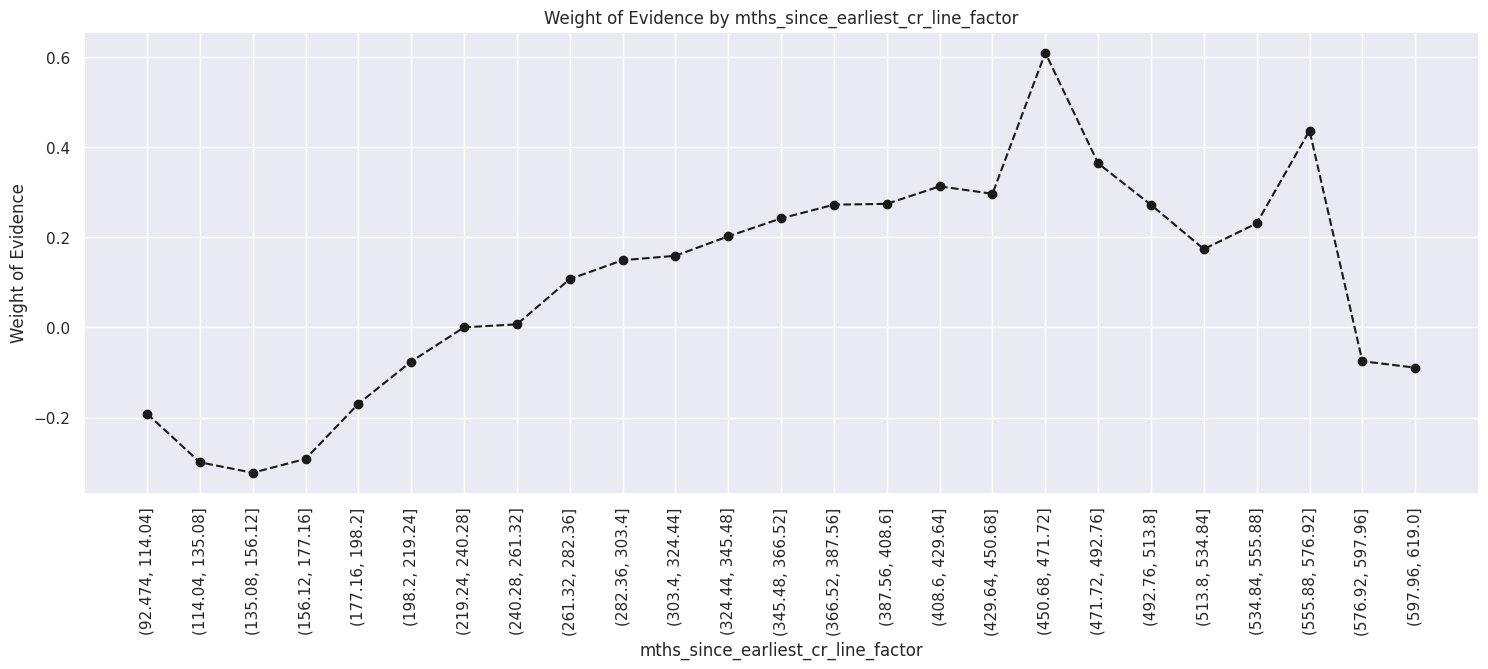

In [83]:
plot_by_woe(df_temp, 90)

In [84]:
# fine-classing
X_train_prepr['mths_since_issue_d_factor'] = pd.cut(X_train_prepr['mths_since_issue_d'], 25)
# preprocess
df_temp = woe_ordered_continuous(X_train_prepr, "mths_since_issue_d_factor", y_train_prepr)
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_issue_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(55.989, 56.44]",35424,1.000000,0.105155,35424.0,0.0,0.107153,0.000000,inf,NaN,NaN,inf
1,"(56.44, 56.88]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
2,"(56.88, 57.32]",29929,0.998029,0.088843,29870.0,59.0,0.090353,0.009393,2.263711,NaN,NaN,inf
3,"(57.32, 57.76]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
4,"(57.76, 58.2]",38907,0.997558,0.115494,38812.0,95.0,0.117401,0.015125,2.049246,NaN,NaN,inf
5,"(58.2, 58.64]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
6,"(58.64, 59.08]",22879,0.993925,0.067915,22740.0,139.0,0.068785,0.022130,1.134045,NaN,NaN,inf
7,"(59.08, 59.52]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
8,"(59.52, 59.96]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
9,"(59.96, 60.4]",28788,0.990621,0.085456,28518.0,270.0,0.086263,0.042987,0.696507,NaN,NaN,inf


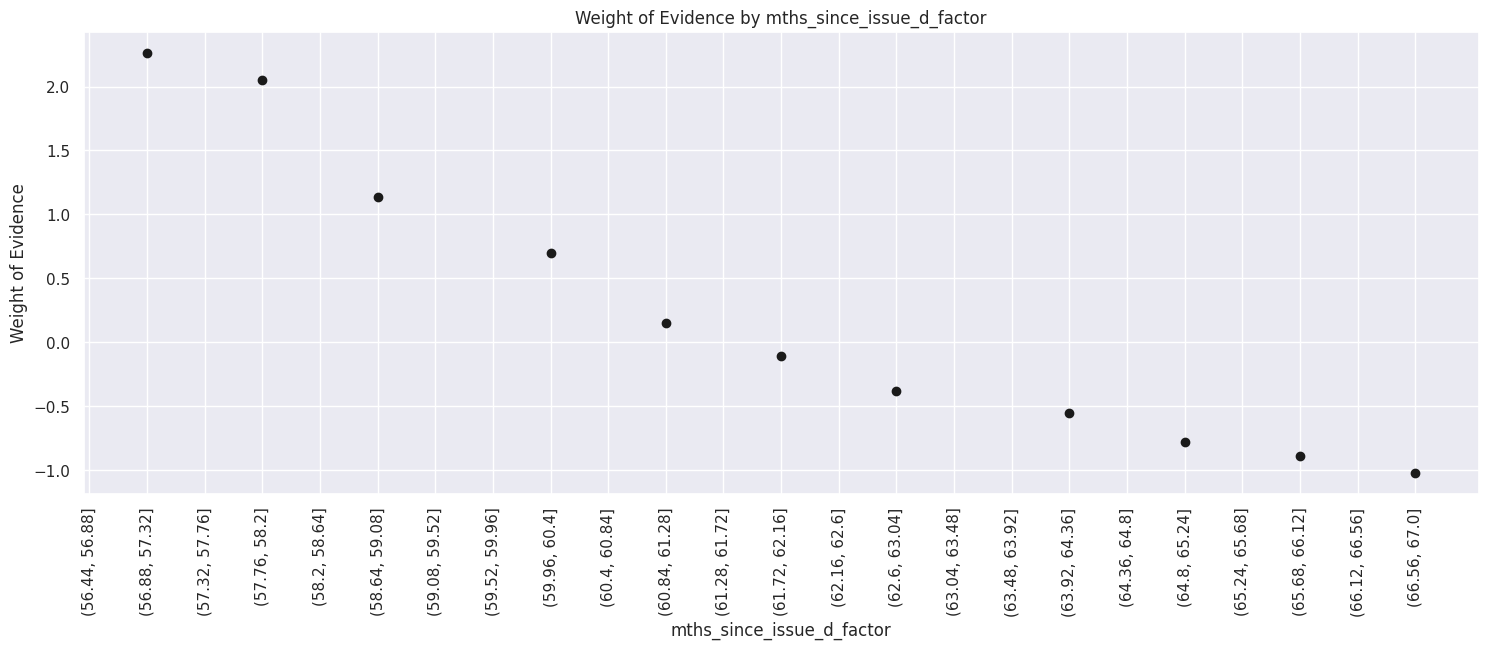

In [85]:
plot_by_woe(df_temp, 90)

In [86]:
# fine-classing
X_train_prepr['mths_since_last_pymnt_d_factor'] = pd.cut(X_train_prepr['mths_since_last_pymnt_d'], 25)
# preprocess
df_temp = woe_ordered_continuous(X_train_prepr, "mths_since_last_pymnt_d_factor", y_train_prepr)
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_last_pymnt_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(54.988, 55.48]",232472,0.998675,0.690084,232164.0,308.0,0.702263,0.049037,2.661738,NaN,NaN,4.334532
1,"(55.48, 55.96]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.334532
2,"(55.96, 56.44]",70914,0.994106,0.210505,70496.0,418.0,0.213240,0.066550,1.164468,NaN,NaN,4.334532
3,"(56.44, 56.92]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.334532
4,"(56.92, 57.4]",3749,0.695385,0.011129,2607.0,1142.0,0.007886,0.181818,-3.137943,NaN,NaN,4.334532
5,"(57.4, 57.88]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.334532
6,"(57.88, 58.36]",3792,0.683017,0.011256,2590.0,1202.0,0.007834,0.191371,-3.195691,NaN,NaN,4.334532
7,"(58.36, 58.84]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.334532
8,"(58.84, 59.32]",2868,0.697699,0.008514,2001.0,867.0,0.006053,0.138035,-3.126998,NaN,NaN,4.334532
9,"(59.32, 59.8]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.334532


In [87]:
# filter out all values > 75 given the low obs
X_train_prepr_temp = X_train_prepr[X_train_prepr['mths_since_last_credit_pull_d'] <= 75].copy()
# Here we do fine-classing: using the 'cut' method, we split the variable into 25 categories
X_train_prepr_temp['mths_since_last_credit_pull_d_factor'] = pd.cut(X_train_prepr_temp['mths_since_last_credit_pull_d'], 25)
# Calculate WoE
df_temp = woe_ordered_continuous(X_train_prepr_temp, "mths_since_last_credit_pull_d_factor", y_train_prepr[X_train_prepr_temp.index])
df_temp

/tmp/ipykernel_3659/2975529868.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
/tmp/ipykernel_3659/2975529868.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_last_credit_pull_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(54.987, 55.52]",322212,0.983291,0.956473,316828.0,5384.0,0.958360,0.857188,0.111566,NaN,NaN,0.194379
1,"(55.52, 56.04]",4252,0.882408,0.012622,3752.0,500.0,0.011349,0.079605,-1.947926,0.100882,2.059491,0.194379
2,"(56.04, 56.56]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.194379
3,"(56.56, 57.08]",2561,0.986724,0.007602,2527.0,34.0,0.007644,0.005413,0.345066,NaN,NaN,0.194379
4,"(57.08, 57.6]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.194379
5,"(57.6, 58.12]",1944,0.984568,0.005771,1914.0,30.0,0.005790,0.004776,0.192391,NaN,NaN,0.194379
6,"(58.12, 58.64]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.194379
7,"(58.64, 59.16]",1632,0.918505,0.004845,1499.0,133.0,0.004534,0.021175,-1.541157,NaN,NaN,0.194379
8,"(59.16, 59.68]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.194379
9,"(59.68, 60.2]",1122,0.930481,0.003331,1044.0,78.0,0.003158,0.012418,-1.369256,NaN,NaN,0.194379


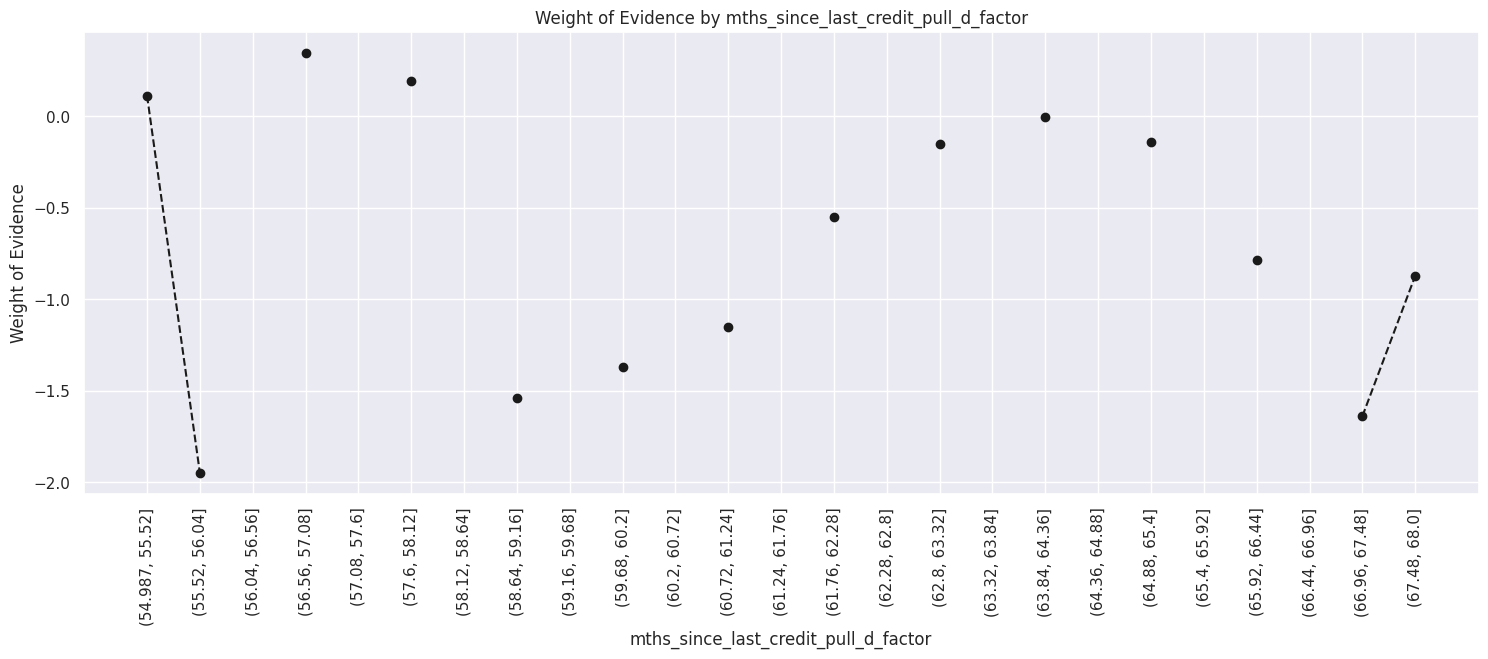

In [88]:
plot_by_woe(df_temp, 90)

In [ ]:
## Define Custom Class for WoE Binning/Reengineering Here we will create a custom scikit-learn class to take care of all binning transformations on any given data set. This custom class will help us in performing k fold cross validation